<a href="https://colab.research.google.com/github/alissonjsb4/applied-computational-intelligence/blob/main/homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOMEWORK 01 INTELIGÊNCIA COMPUTACIONAL APLICADA
Esse notebook contém o código utilizado para realizar tratamento e análise dos dados referentes ao homework 01 da disciplina de Inteligência Computacional Aplicada (ICA), no periodo letivo 2026.2 ministrada pela professora Phd. Michela Mulas para o curso de engenharia de computação.

Autores:

Icaro Adriano 609310 (Departamento de Engenharia de Teleinformatica)

Matheus Reis matricula (Departamento de Engenharia de Teleinformatica)

Alisson Jaime matricula (Departamento de Engenharia de Teleinformatica)

# DESCRIÇÃO DO DATASET

Como primeiro passo da análise, para conhecer o dataset de original, importa-se o dataset em formato csv, transformando-o em objeto dataframe do pandas, e printa-se o head do dataframe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/diabetes_risk_prediction_dataset.csv') # Lê um csv e transforma em um objeto rabela do pandas
saida = 'Diabetes_Risk_Score'

print(df.head()) # printa o head do dataframe

   Patient_ID   Age Gender        Country  Height_cm  Weight_kg   BMI  \
0           1  32.0   Male         Mexico      182.1       65.8  19.8   
1           2  42.0  Other   Saudi Arabia      148.5      101.2  45.9   
2           3  89.0  Other      Argentina      158.1        NaN  37.9   
3           4  87.0  Other  United States      190.9       95.9  26.3   
4           5  27.0  Other      Australia      156.9      101.9  41.4   

   Waist_Circumference_cm  Blood_Glucose  HbA1c  ...  Fatty_Liver  PCOS  \
0                    71.2           88.4   10.4  ...          Yes    No   
1                   121.8          247.3   11.3  ...          Yes   Yes   
2                   131.8          141.9    6.3  ...          Yes    No   
3                    99.1           90.1    7.4  ...           No    No   
4                    77.1           93.8   12.0  ...          Yes   Yes   

   Medication_Adherence   Work_Type  Residence_Type  Daily_Water_Intake_L  \
0                  Good     Retir

Em seguida, contamos o número de observações N, e de preditores D.

In [2]:
rows, columns = df.shape

print('número de linhas N: ', rows)
print('número de colunas: ', columns)


número de linhas N:  50000
número de colunas:  41


A partir dessas informações já nos é possível constatar que o número de observações é de 50000, que corresponde ao numero de linhas de um dataframe pandas, já o número de preditores depende de quantas variáveis queremos predizer, como o dataset não foi um dos contidos no exercício proposto, ainda faremos uma limpeza anterior, mas queremos predizer apenas o atributo Diabetes_Risk_Score, logo nosso número de preditores é inicialmente 40.

Para determinarmos as classes e sua distribuição iremos filtrar apenas os preditores qualitativos, e fazer a contagem dos diferentes valores destes.

In [3]:
preditores = df.drop(columns=[saida]) # Insere a coluna com nome da variavel saida em uma variavel preditores

def print_classes(dataframe):
    preditores_qualitativos = dataframe.select_dtypes(include=['object', 'category', 'string']) # pega os atributos com tipo especificado como argumento

    df_derretido = preditores_qualitativos.melt(var_name='Preditor', value_name='Valor') # transforma atributos em uma nova coluna cujos valores são os nomes dos atributos anteriores
    ocorrencias = df_derretido.value_counts(subset=['Preditor', 'Valor'])
    total_classes = len(ocorrencias)

    print("Distribuição de classes:")
    print(ocorrencias.to_string())
    print("Total de classes L:", total_classes)
    return

print_classes(preditores)

Distribuição de classes:
Preditor                    Valor                              
Doctor_Consultation_Needed  Yes                                    46426
Diabetes_Risk               High                                   36593
Heart_Disease               No                                     25288
Hypertension                Yes                                    25200
Fatty_Liver                 No                                     25155
Residence_Type              Urban                                  25129
Family_History_Diabetes     No                                     25076
PCOS                        No                                     25071
                            Yes                                    24929
Family_History_Diabetes     Yes                                    24924
Residence_Type              Rural                                  24871
Fatty_Liver                 Yes                                    24845
Hypertension                No     

Devido ao número excessivo de classes, todas as classes não relacionadas a nacionalidade e gênero serão removidas

In [4]:
preditores_quantitativos = preditores.select_dtypes(include=['int','float'])
preditores_qualitativos = preditores[['Country','Gender']]

preditores = pd.concat([preditores_quantitativos, preditores_qualitativos], axis=1)

print(preditores.head)

print_classes(preditores)

<bound method NDFrame.head of        Patient_ID   Age  Height_cm  Weight_kg   BMI  Waist_Circumference_cm  \
0               1  32.0      182.1       65.8  19.8                    71.2   
1               2  42.0      148.5      101.2  45.9                   121.8   
2               3  89.0      158.1        NaN  37.9                   131.8   
3               4  87.0      190.9       95.9  26.3                    99.1   
4               5  27.0      156.9      101.9  41.4                    77.1   
...           ...   ...        ...        ...   ...                     ...   
49995       49996  52.0      153.9      107.4  45.3                    75.9   
49996       49997  53.0      179.6       64.0  19.8                   114.5   
49997       49998  88.0      194.1       65.6  17.4                    96.1   
49998       49999  23.0      168.0       73.9  26.2                   131.4   
49999       50000  24.0      152.8       94.6  40.5                    66.1   

       Blood_Glucose 

Um número mais plausível de classes. Esse será o dataset utilizado para análise. Agora iremos extrair o número de preditores, o número de observações, e a distribuição das classes.

In [5]:
rows, columns = preditores.shape

print('Número de observações N: ', rows)
print('Número de preditores P: ', columns)
print('Distribuição de classses: ')
print_classes(preditores)

Número de observações N:  50000
Número de preditores P:  23
Distribuição de classses: 
Distribuição de classes:
Preditor  Valor         
Gender    Male              16718
          Other             16677
          Female            16605
Country   Malaysia           2083
          Russia             2071
          France             2068
          China              2065
          Canada             2050
          United Kingdom     2037
          Nigeria            2023
          Indonesia          2011
          Egypt              2010
          Spain              2007
          Mexico             1999
          Germany            1999
          South Korea        1997
          South Africa       1996
          Italy              1989
          Turkey             1984
          Japan              1983
          India              1974
          Bangladesh         1970
          Brazil             1967
          Pakistan           1959
          Australia          1956
          Uni

# ANÁLISE MONOVARIADA INCONDICIONAL
Por seguinte realizaremos uma análise monovariada sem discriminação por classes, extraindo a media, mediana, desvio padrão e assimetría de cada atributo, além de plotar seus histogramas e gráficos de caixa.

Column  Patient_ID data: 
Patient_ID mean:  25000.5
Patient_ID skewness:  0.0
Patient_ID standart deviation:  14433.90106658626


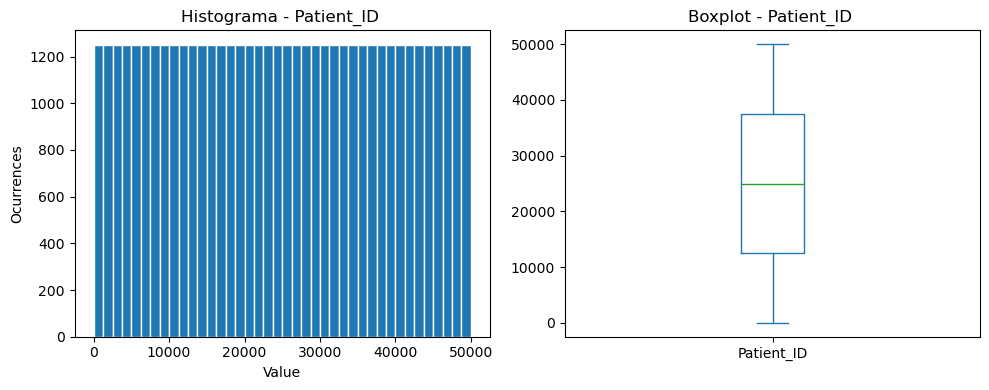

Column  Age data: 
Age mean:  53.87109872128962
Age skewness:  0.007512839687922029
Age standart deviation:  21.1301476973126


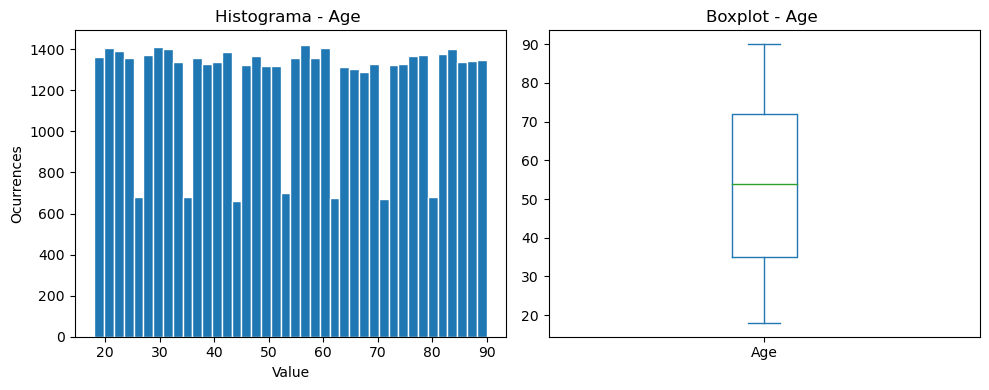

Column  Height_cm data: 
Height_cm mean:  170.01881415364997
Height_cm skewness:  0.0004208829321031421
Height_cm standart deviation:  14.457786611277559


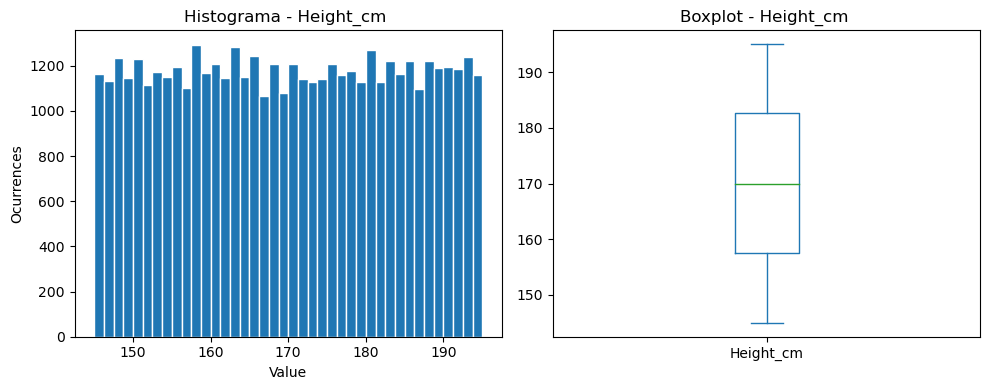

Column  Weight_kg data: 
Weight_kg mean:  87.45700284876058
Weight_kg skewness:  0.0042446766777343116
Weight_kg standart deviation:  24.50035783911258


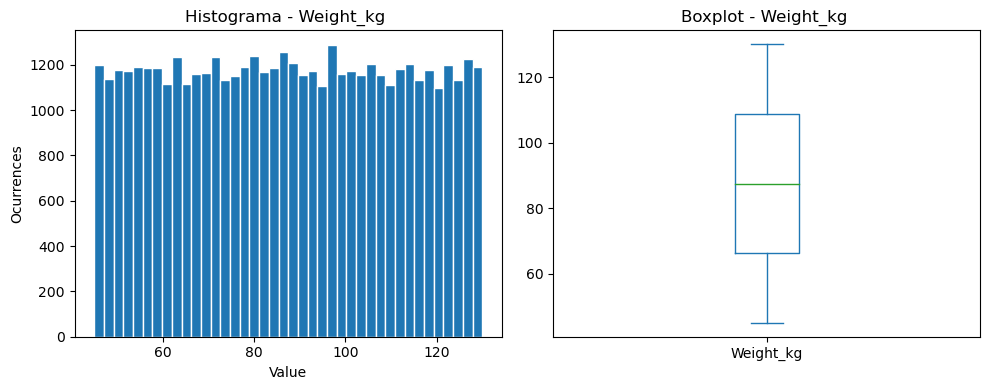

Column  BMI data: 
BMI mean:  30.924056
BMI skewness:  0.4317694129827958
BMI standart deviation:  10.290090661805685


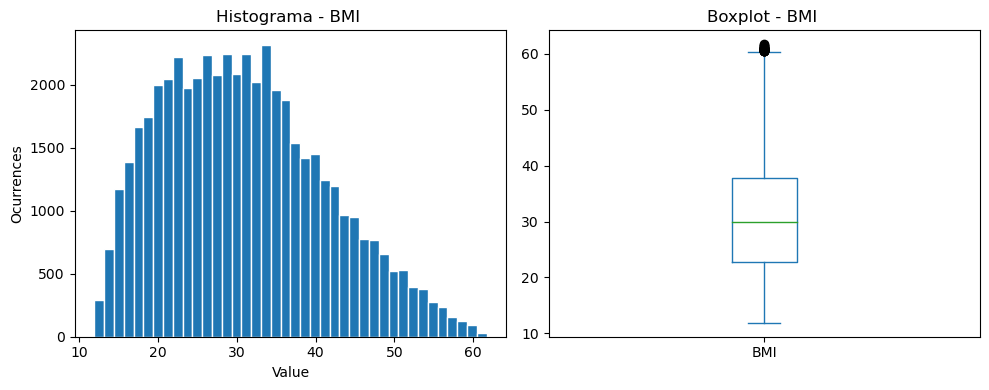

Column  Waist_Circumference_cm data: 
Waist_Circumference_cm mean:  99.96078999999997
Waist_Circumference_cm skewness:  0.009688430624564214
Waist_Circumference_cm standart deviation:  23.086578693652626


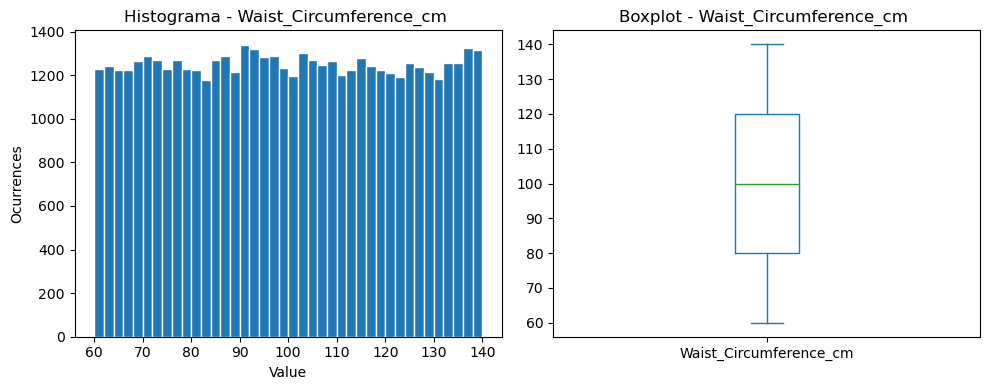

Column  Blood_Glucose data: 
Blood_Glucose mean:  159.90524459126038
Blood_Glucose skewness:  0.006298453438570136
Blood_Glucose standart deviation:  52.04057479292049


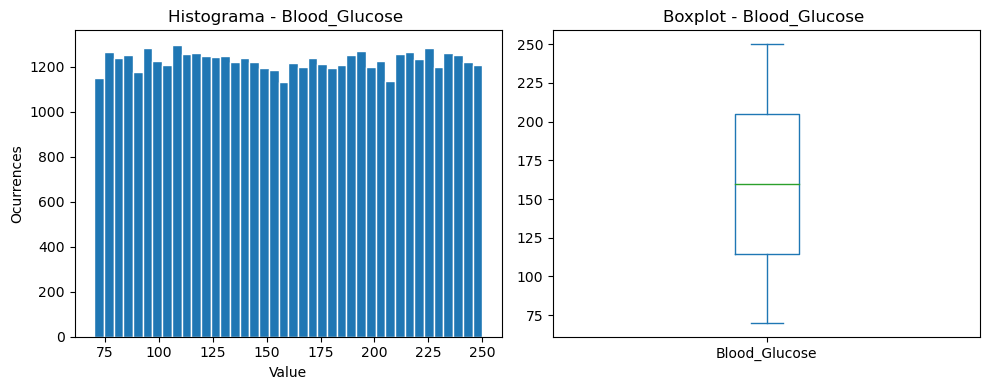

Column  HbA1c data: 
HbA1c mean:  8.488060633823345
HbA1c skewness:  0.0017092351750398538
HbA1c standart deviation:  2.313758112953104


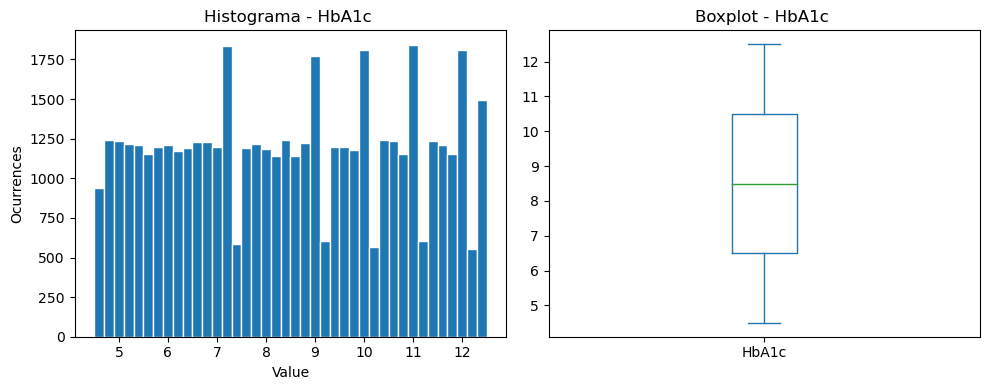

Column  Fasting_Blood_Sugar data: 
Fasting_Blood_Sugar mean:  142.607294
Fasting_Blood_Sugar skewness:  -0.0012380502410888924
Fasting_Blood_Sugar standart deviation:  44.681799465348675


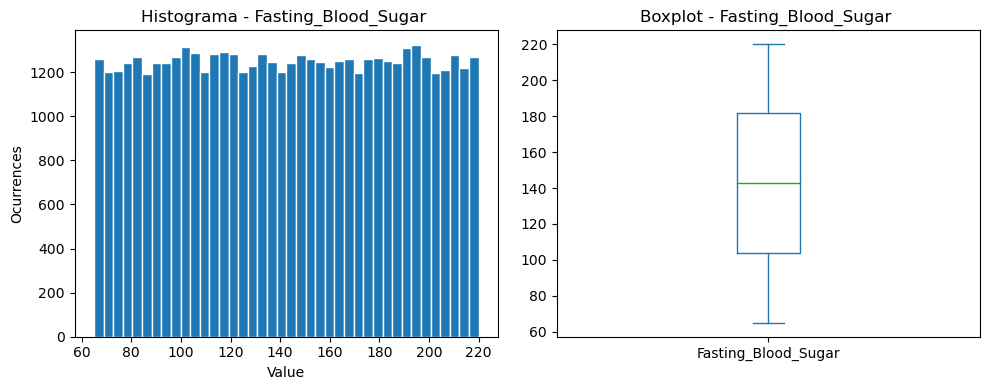

Column  Insulin_Level data: 
Insulin_Level mean:  23.476724
Insulin_Level skewness:  0.005540187089203176
Insulin_Level standart deviation:  12.403841345866477


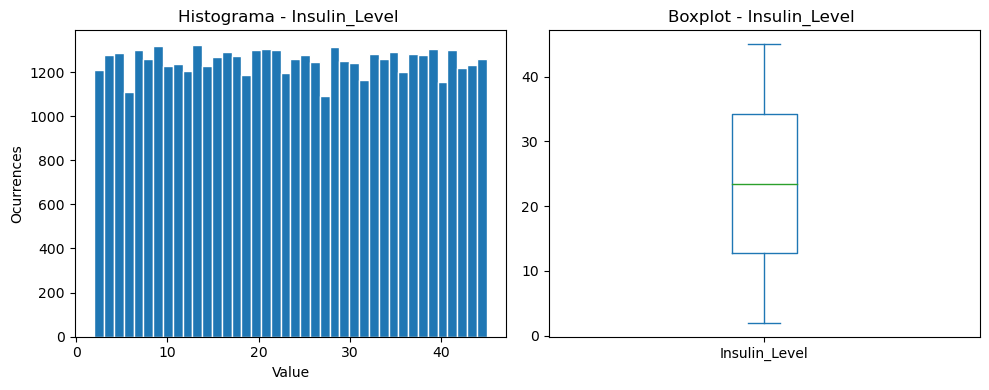

Column  Blood_Pressure_Systolic data: 
Blood_Pressure_Systolic mean:  140.17112
Blood_Pressure_Systolic skewness:  -0.0037586993782831287
Blood_Pressure_Systolic standart deviation:  29.16862310972327


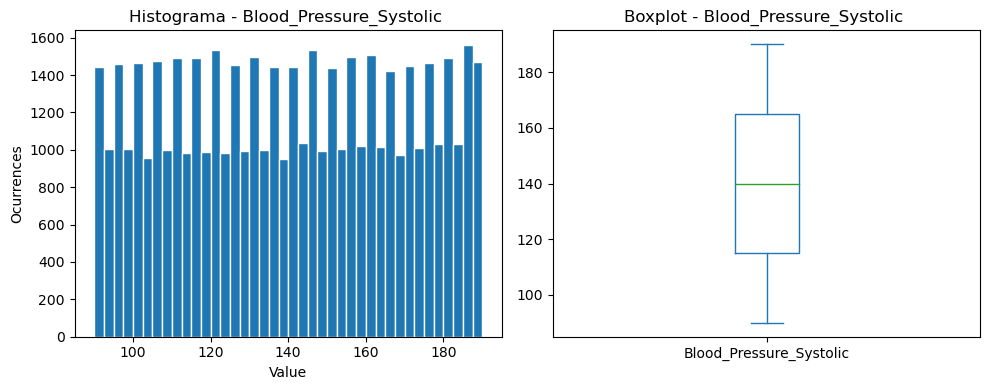

Column  Blood_Pressure_Diastolic data: 
Blood_Pressure_Diastolic mean:  90.039
Blood_Pressure_Diastolic skewness:  -0.00958019288838675
Blood_Pressure_Diastolic standart deviation:  17.575502751441828


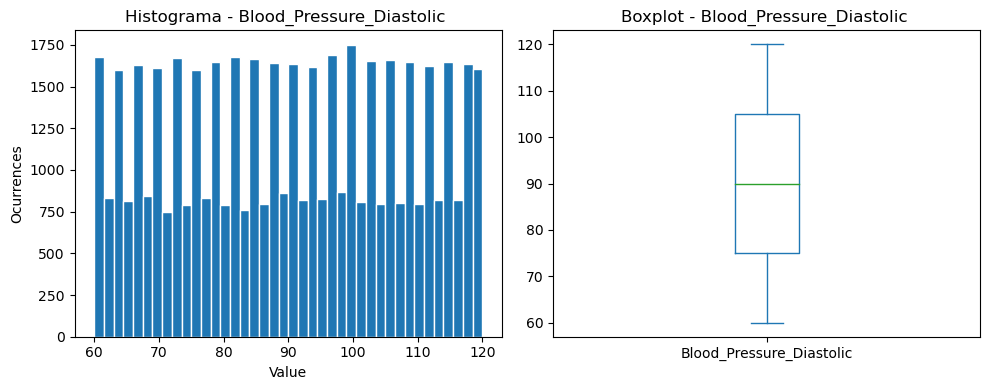

Column  Total_Cholesterol data: 
Total_Cholesterol mean:  220.16863469387758
Total_Cholesterol skewness:  -0.005052912473231308
Total_Cholesterol standart deviation:  57.793626169978666


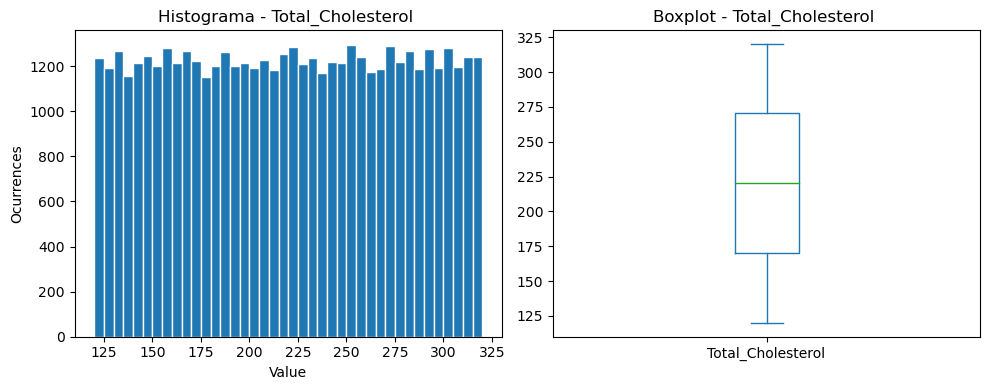

Column  HDL data: 
HDL mean:  57.371730612244896
HDL skewness:  0.003957540464458472
HDL standart deviation:  18.720696124390916


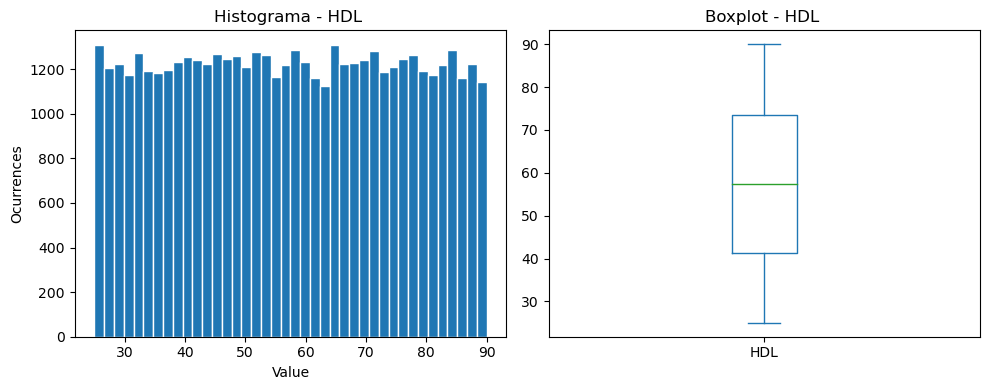

Column  LDL data: 
LDL mean:  135.01452448979592
LDL skewness:  -0.004072407154016737
LDL standart deviation:  49.13561345314557


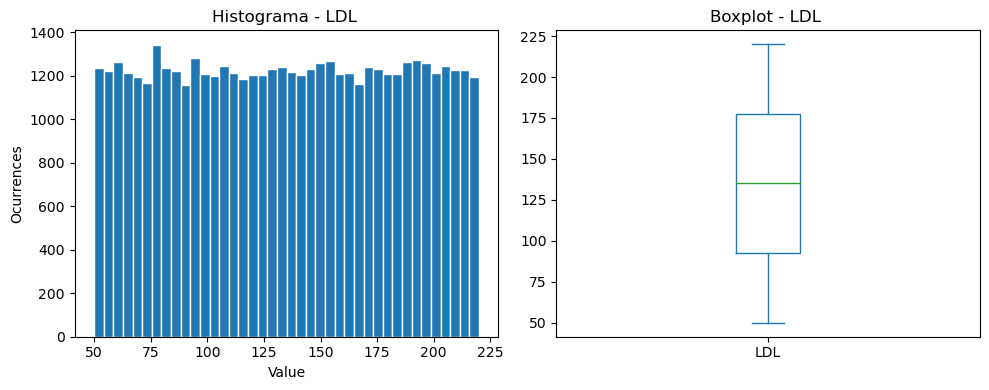

Column  Triglycerides data: 
Triglycerides mean:  229.54325918367346
Triglycerides skewness:  -6.94766743861743e-05
Triglycerides standart deviation:  98.23491079136728


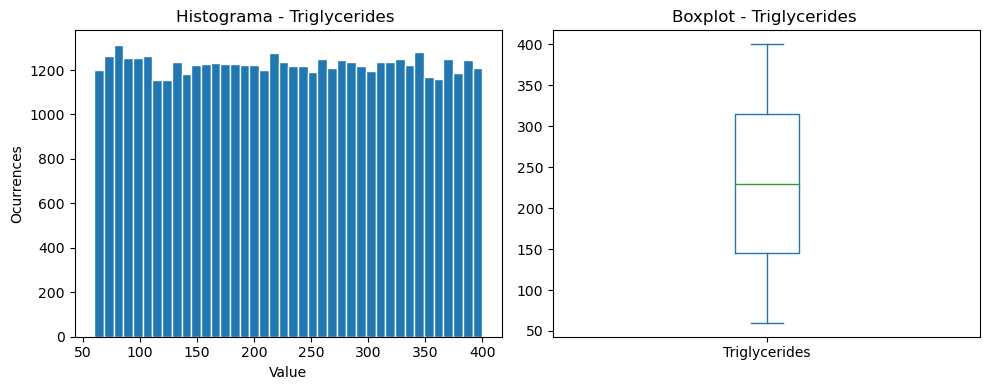

Column  Heart_Rate data: 
Heart_Rate mean:  85.12426
Heart_Rate skewness:  -0.014701556215837333
Heart_Rate standart deviation:  20.390334346623533


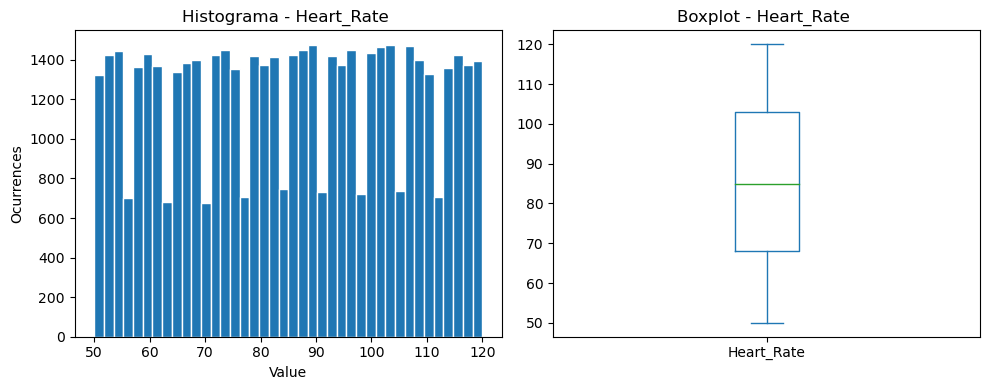

Column  Exercise_Hours_Per_Week data: 
Exercise_Hours_Per_Week mean:  5.017459590068321
Exercise_Hours_Per_Week skewness:  -0.009296615876169754
Exercise_Hours_Per_Week standart deviation:  2.8759219857896814


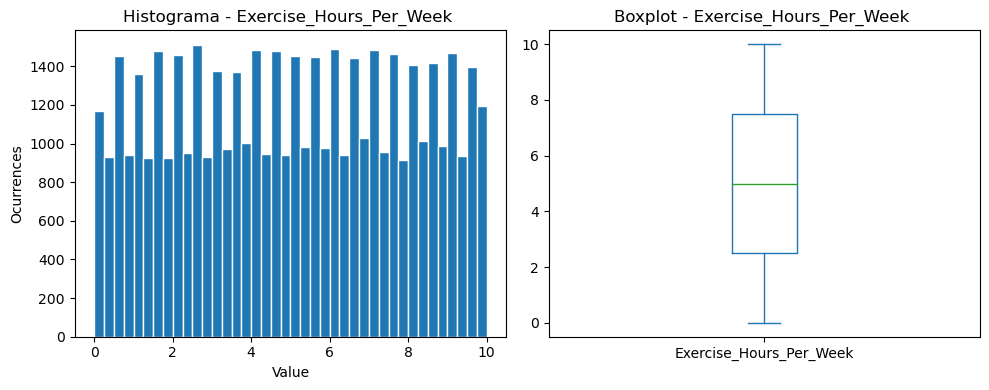

Column  Daily_Walking_Minutes data: 
Daily_Walking_Minutes mean:  89.93344158547755
Daily_Walking_Minutes skewness:  0.004699035128514406
Daily_Walking_Minutes standart deviation:  52.03464227071244


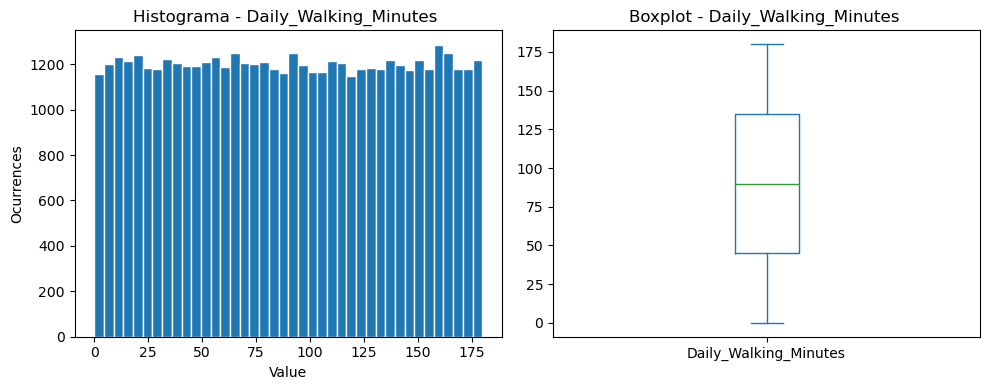

Column  Sleep_Hours data: 
Sleep_Hours mean:  6.500916991434466
Sleep_Hours skewness:  -0.005070828719186197
Sleep_Hours standart deviation:  2.0277929024217074


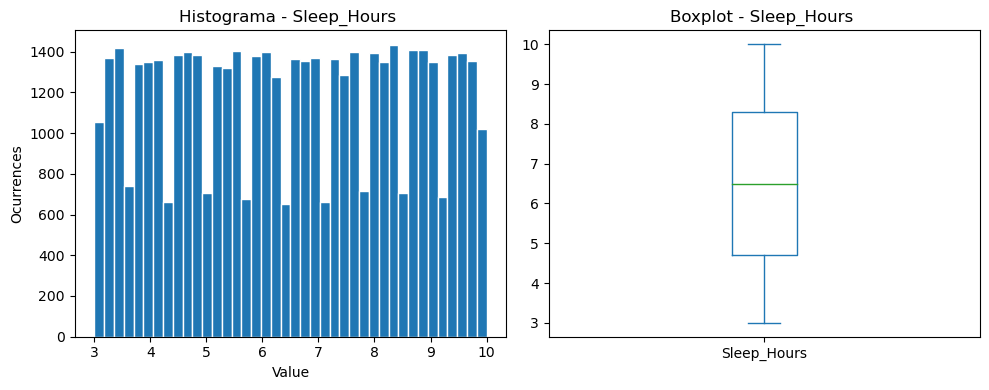

Column  Daily_Water_Intake_L data: 
Daily_Water_Intake_L mean:  2.9988420000000002
Daily_Water_Intake_L skewness:  0.0032439617943331245
Daily_Water_Intake_L standart deviation:  1.1522728035010954


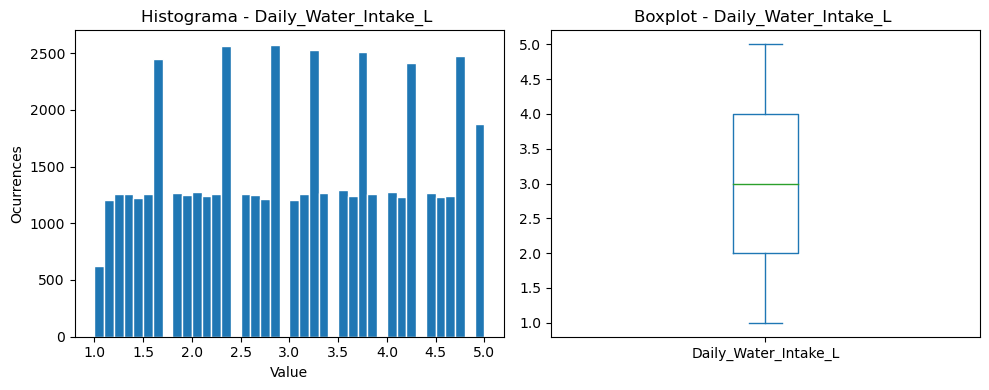

In [8]:
import matplotlib.pyplot as plt

def print_statistics(dataframe, column):
    mean = dataframe[column].mean()
    std = dataframe[column].std()
    skewness = dataframe[column].skew()

    
    print(column, 'mean: ', mean)
    print(column, 'skewness: ', skewness)
    print(column, 'standart deviation: ', std)
    return

def plot_hist_and_box(dataframe, column, group=''):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    dataframe[column].plot(kind='hist', ax=axes[0], bins=40, edgecolor='white', title=f'Histograma - {column} {group}')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Ocurrences')
    
    dataframe[column].plot(kind='box', ax=axes[1], title=f'Boxplot - {column} {group}')
    
    plt.tight_layout()
    plt.show()
    return

for columns in preditores_quantitativos:
    print('Column ', columns, 'data: ')
    print_statistics(preditores_quantitativos, columns)
    plot_hist_and_box(preditores_quantitativos, columns)

# ANÁLISE MONOVARIADA CONDICIONAL

CONDITIONAL ANALYSIS ON Gender 

Statistics and plots for Gender = Female
Patient_ID mean:  24903.39608551641
Patient_ID skewness:  0.003780090177287323
Patient_ID standart deviation:  14448.862980805234


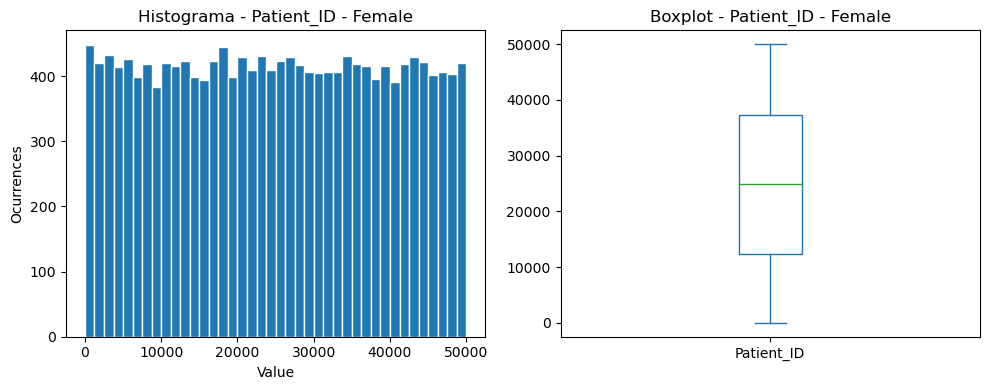

Statistics and plots for Gender = Female
Age mean:  54.00632411067194
Age skewness:  0.003206631667040052
Age standart deviation:  21.132335665904375


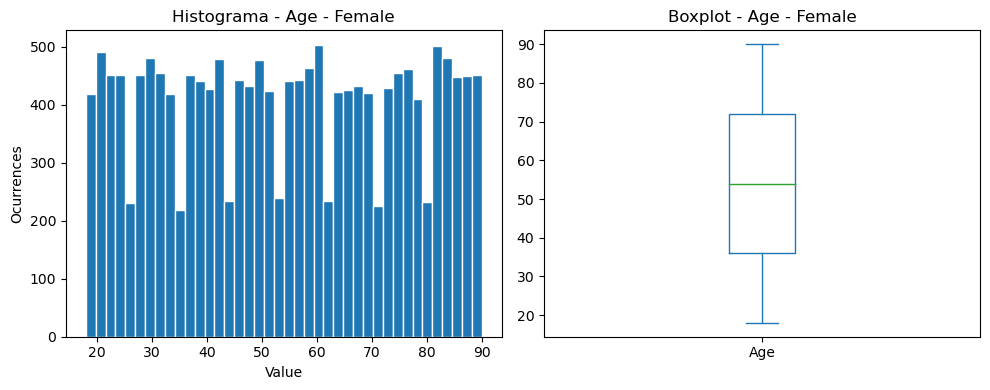

Statistics and plots for Gender = Female
Height_cm mean:  170.05726626991748
Height_cm skewness:  -0.007098968654461978
Height_cm standart deviation:  14.474265777402888


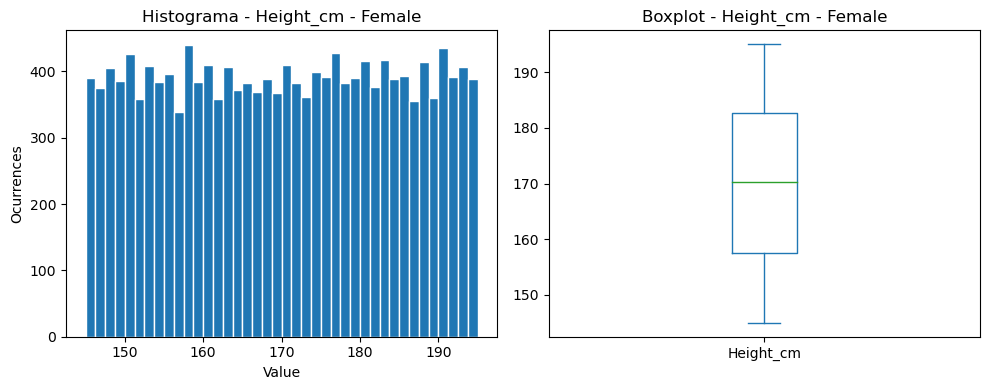

Statistics and plots for Gender = Female
Weight_kg mean:  87.33114355231145
Weight_kg skewness:  0.008487859660957248
Weight_kg standart deviation:  24.40674163137409


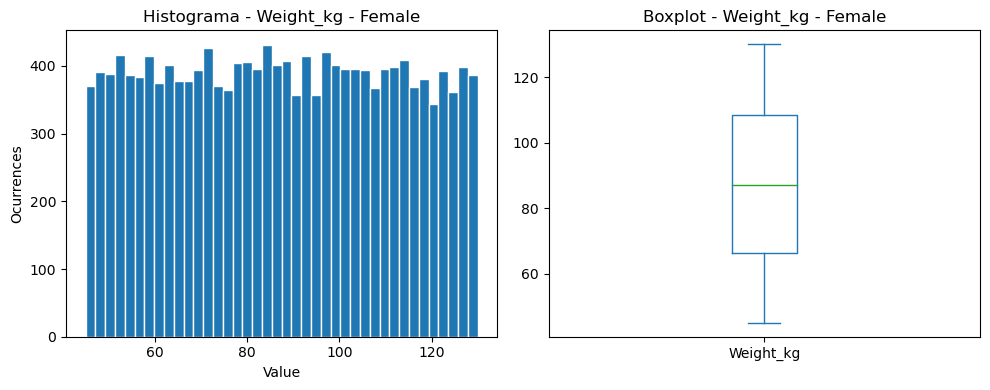

Statistics and plots for Gender = Female
BMI mean:  30.860427582053592
BMI skewness:  0.433325405846464
BMI standart deviation:  10.284968868013467


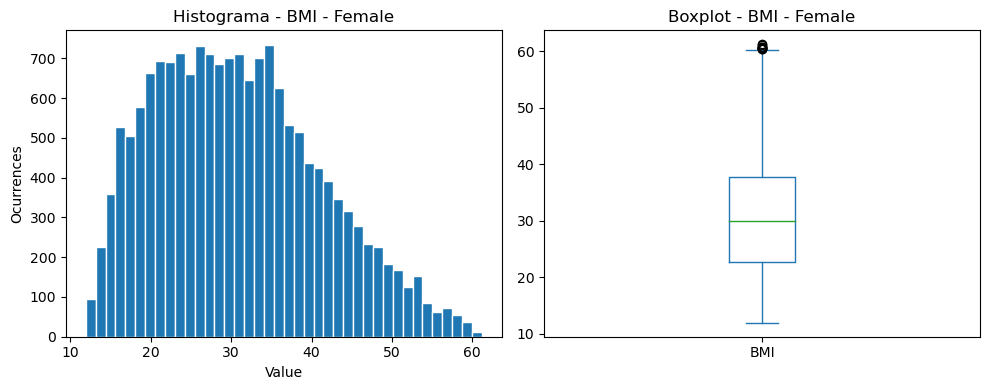

Statistics and plots for Gender = Female
Waist_Circumference_cm mean:  100.04210779885577
Waist_Circumference_cm skewness:  0.0031858254593802025
Waist_Circumference_cm standart deviation:  23.076892325897035


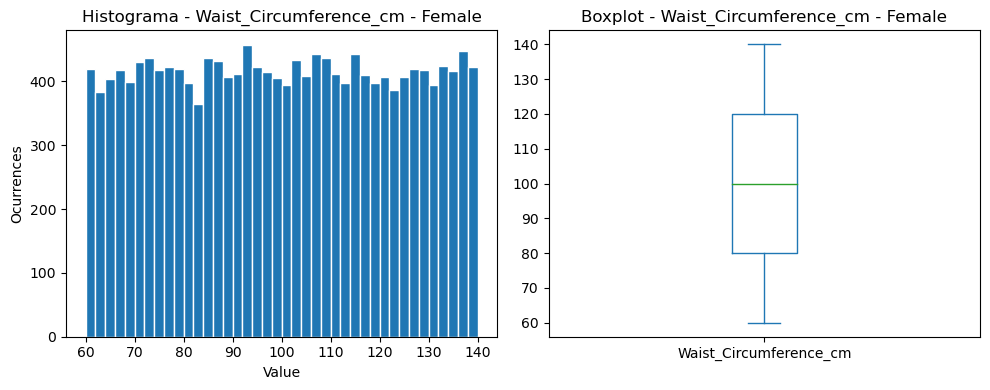

Statistics and plots for Gender = Female
Blood_Glucose mean:  159.9208384483182
Blood_Glucose skewness:  0.0064593536064156245
Blood_Glucose standart deviation:  52.04030746536152


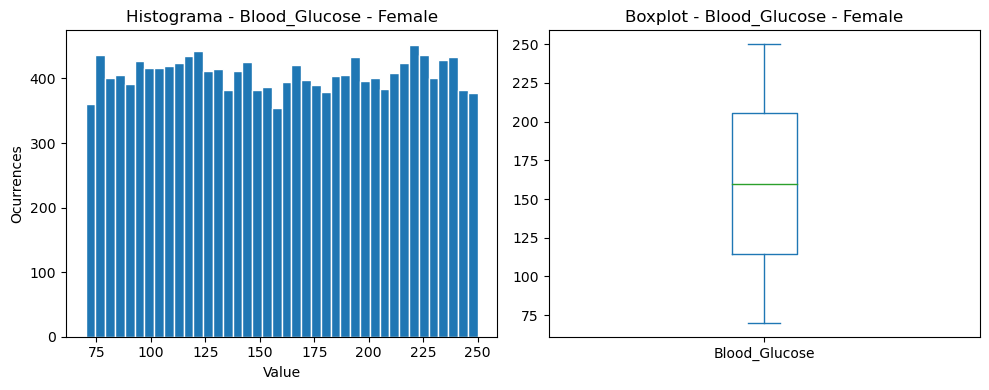

Statistics and plots for Gender = Female
HbA1c mean:  8.500828469214836
HbA1c skewness:  -0.00036008878827069074
HbA1c standart deviation:  2.3144397268718233


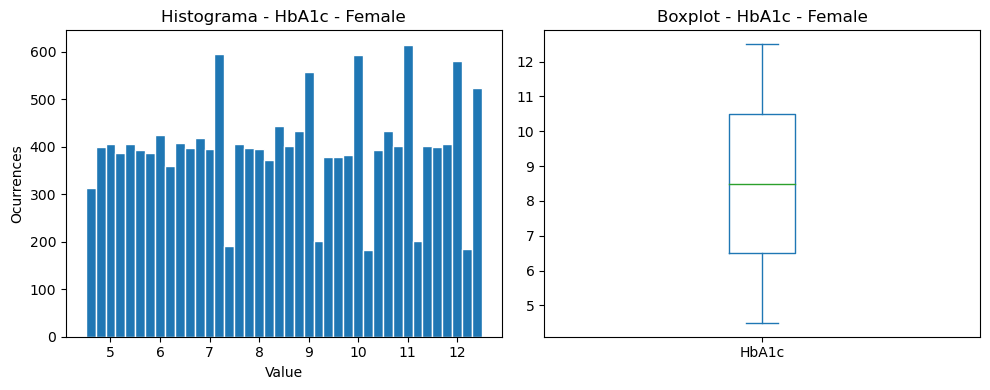

Statistics and plots for Gender = Female
Fasting_Blood_Sugar mean:  142.8333995784402
Fasting_Blood_Sugar skewness:  -0.008941811756785214
Fasting_Blood_Sugar standart deviation:  44.89846979054263


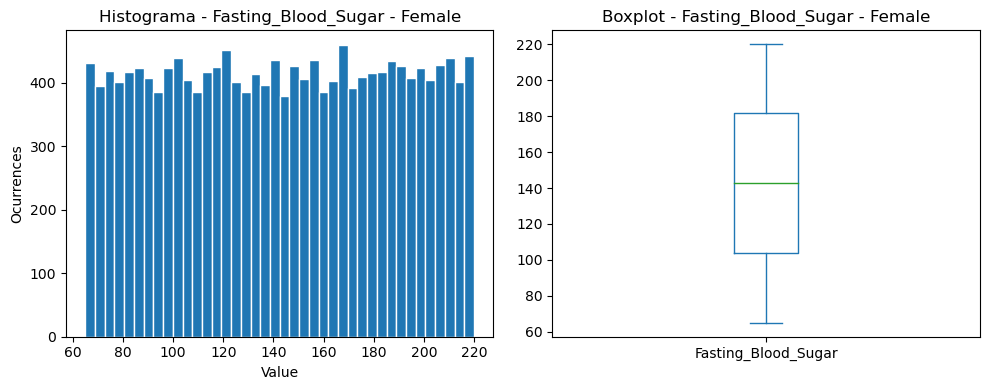

Statistics and plots for Gender = Female
Insulin_Level mean:  23.44763625414032
Insulin_Level skewness:  0.0069114499709389335
Insulin_Level standart deviation:  12.40415881264716


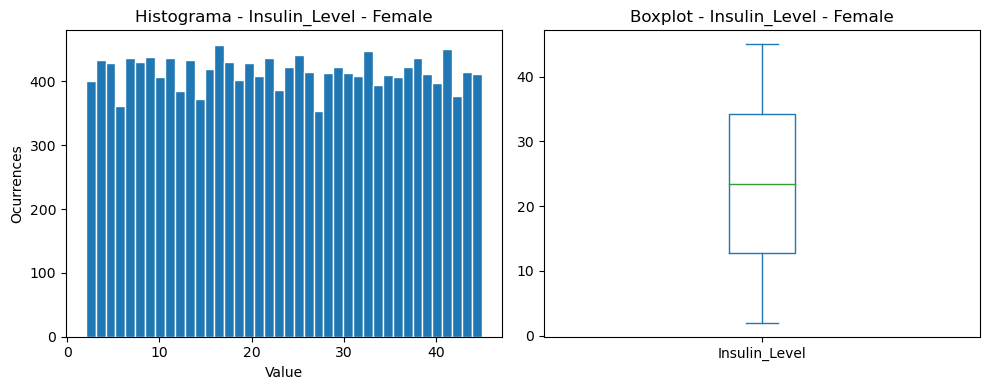

Statistics and plots for Gender = Female
Blood_Pressure_Systolic mean:  140.03095453176755
Blood_Pressure_Systolic skewness:  0.0074966523933350585
Blood_Pressure_Systolic standart deviation:  29.314939883883923


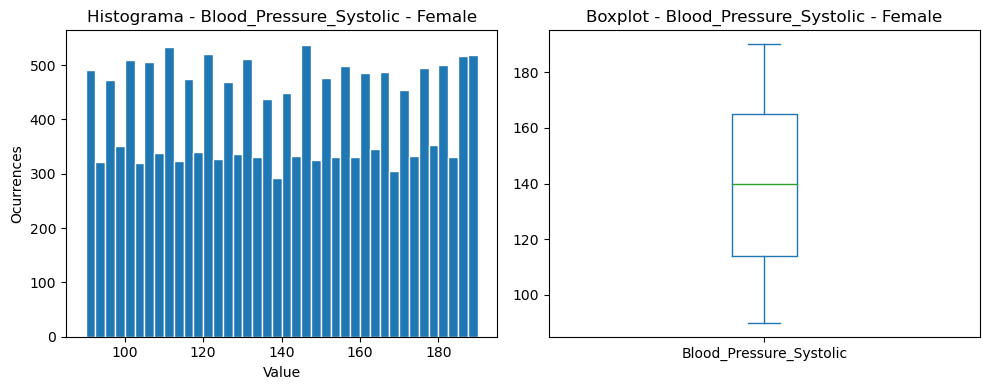

Statistics and plots for Gender = Female
Blood_Pressure_Diastolic mean:  90.05564588979223
Blood_Pressure_Diastolic skewness:  -0.014215199626675603
Blood_Pressure_Diastolic standart deviation:  17.522629796884512


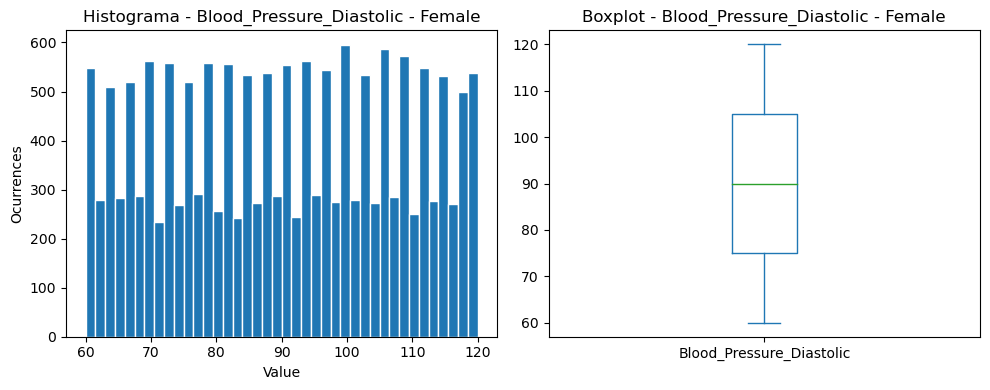

Statistics and plots for Gender = Female
Total_Cholesterol mean:  220.62964716006883
Total_Cholesterol skewness:  -0.017770695605359498
Total_Cholesterol standart deviation:  57.89584135329323


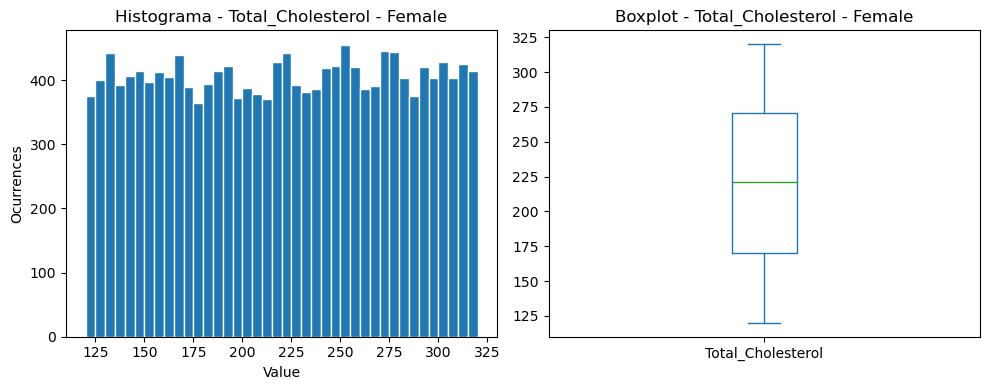

Statistics and plots for Gender = Female
HDL mean:  57.34003812569179
HDL skewness:  0.019148995556945252
HDL standart deviation:  18.728922993479543


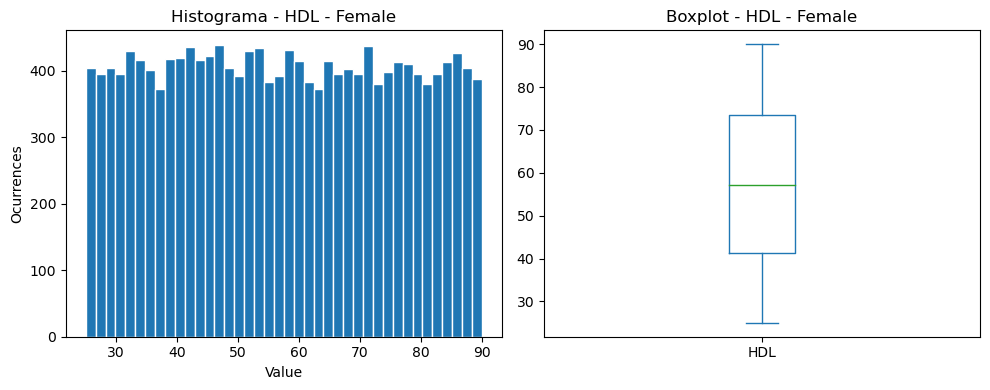

Statistics and plots for Gender = Female
LDL mean:  134.8709171433844
LDL skewness:  -0.002435722280780028
LDL standart deviation:  49.06789070241196


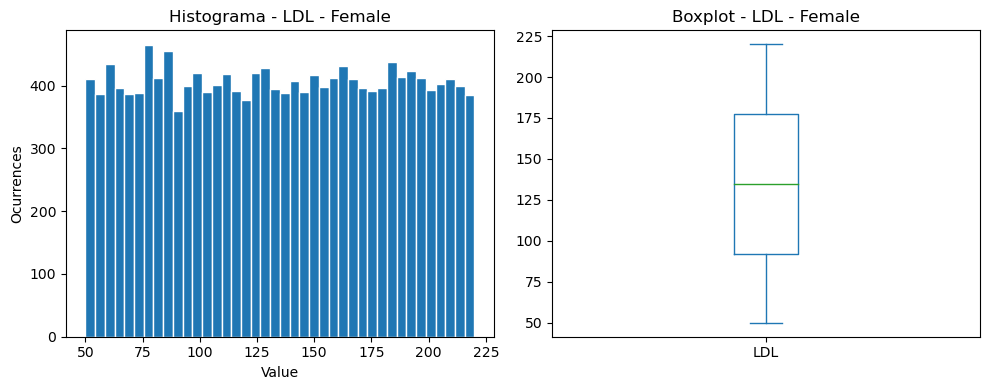

Statistics and plots for Gender = Female
Triglycerides mean:  229.51508657742846
Triglycerides skewness:  0.001850403697296633
Triglycerides standart deviation:  97.87564988096373


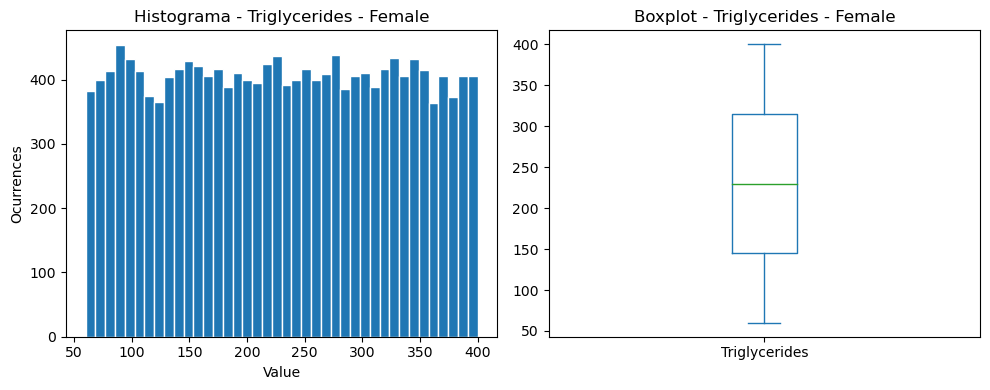

Statistics and plots for Gender = Female
Heart_Rate mean:  85.03384522734116
Heart_Rate skewness:  -0.009655637811124855
Heart_Rate standart deviation:  20.34273155781522


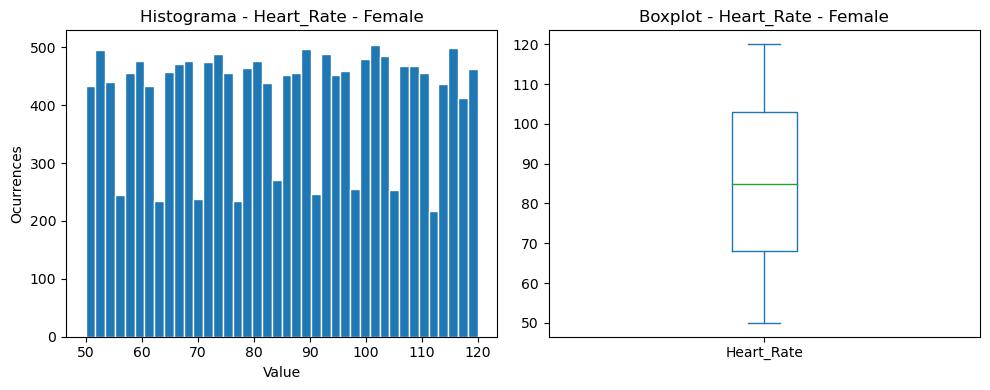

Statistics and plots for Gender = Female
Exercise_Hours_Per_Week mean:  5.055391664574441
Exercise_Hours_Per_Week skewness:  -0.03059268360149355
Exercise_Hours_Per_Week standart deviation:  2.891000701800785


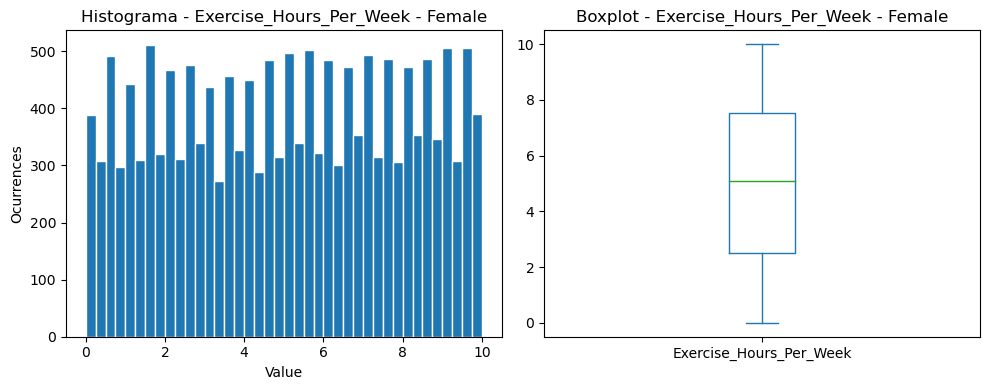

Statistics and plots for Gender = Female
Daily_Walking_Minutes mean:  90.33343565969177
Daily_Walking_Minutes skewness:  -0.0022233827140950035
Daily_Walking_Minutes standart deviation:  52.087685780071524


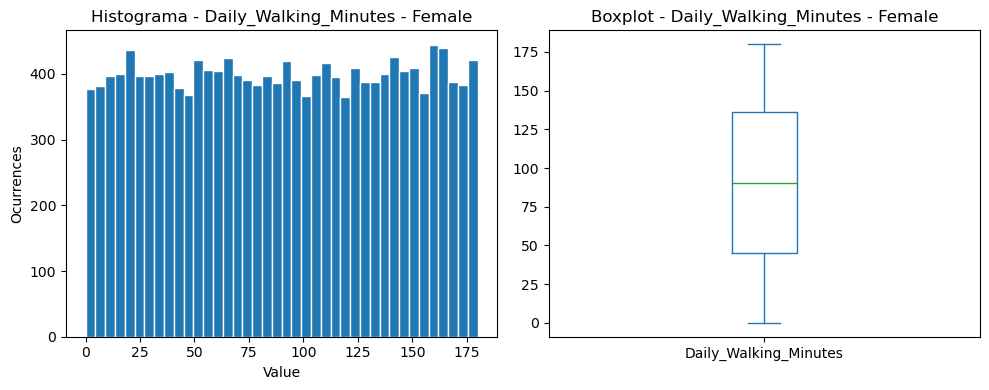

Statistics and plots for Gender = Female
Sleep_Hours mean:  6.484517384209866
Sleep_Hours skewness:  0.0071295038567277536
Sleep_Hours standart deviation:  2.028919925337965


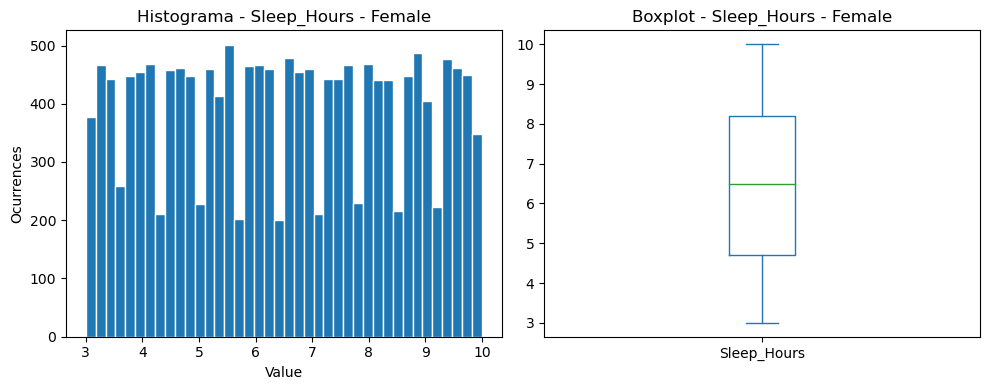

Statistics and plots for Gender = Female
Daily_Water_Intake_L mean:  3.006094549834387
Daily_Water_Intake_L skewness:  -0.0076438951138585245
Daily_Water_Intake_L standart deviation:  1.1504030075208977


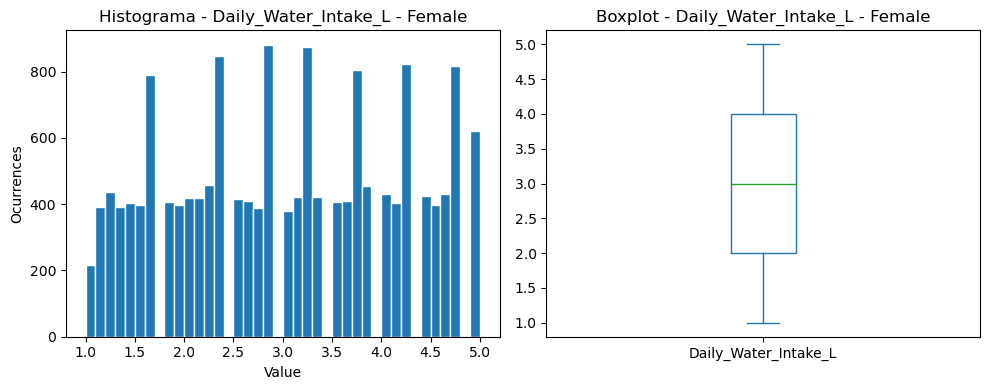

Statistics and plots for Gender = Male
Patient_ID mean:  25105.675320014358
Patient_ID skewness:  -0.012237809456748438
Patient_ID standart deviation:  14406.414947888768


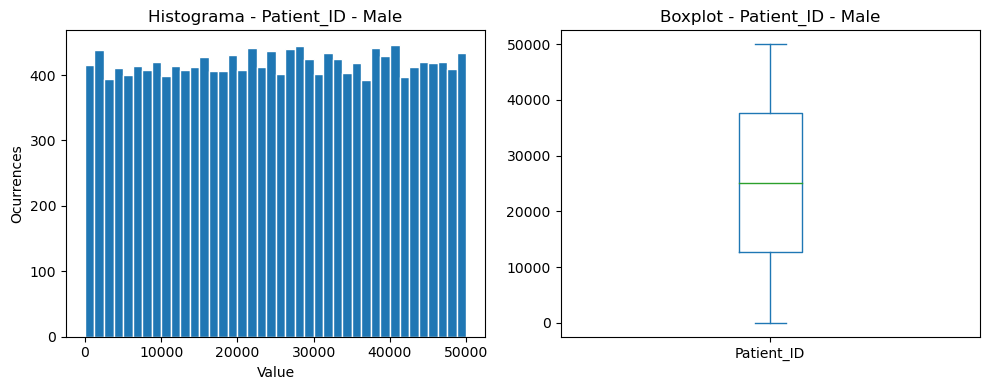

Statistics and plots for Gender = Male
Age mean:  53.786529749320444
Age skewness:  0.0076859973980702425
Age standart deviation:  21.157083487958566


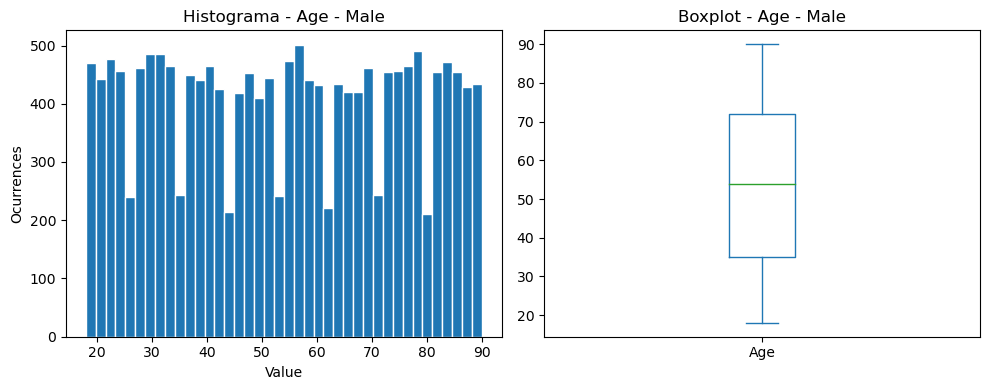

Statistics and plots for Gender = Male
Height_cm mean:  170.05939128224676
Height_cm skewness:  0.0033730562961825196
Height_cm standart deviation:  14.41916924871179


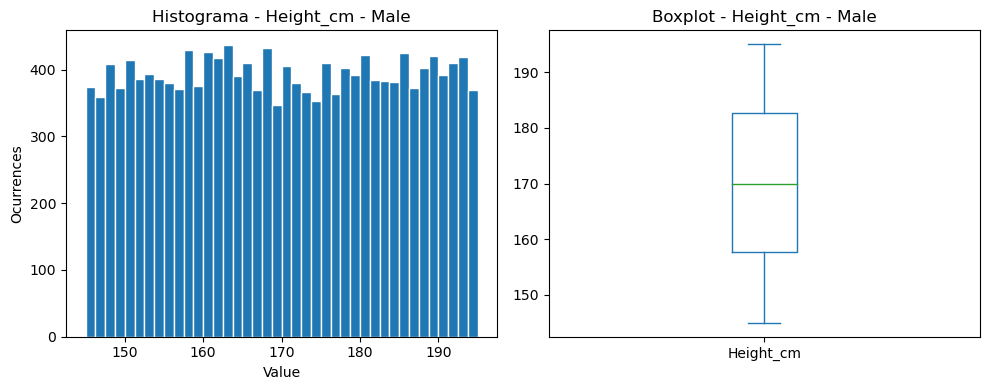

Statistics and plots for Gender = Male
Weight_kg mean:  87.70275976090551
Weight_kg skewness:  -0.013681425429195829
Weight_kg standart deviation:  24.500595963325384


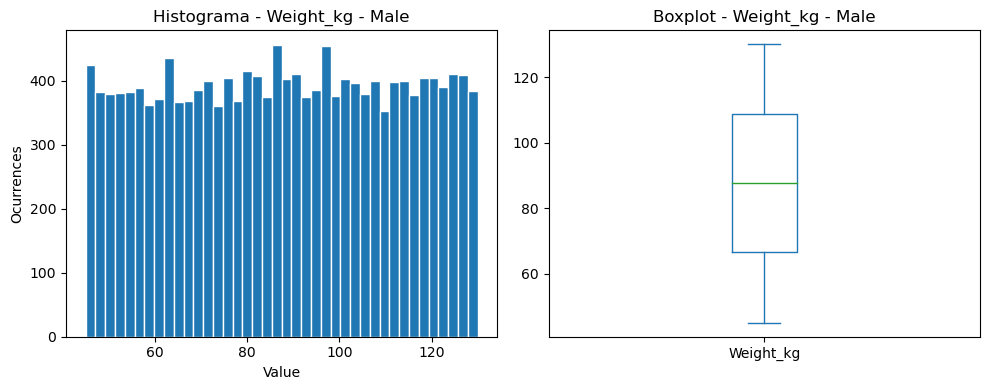

Statistics and plots for Gender = Male
BMI mean:  31.005538940064604
BMI skewness:  0.420991950332708
BMI standart deviation:  10.28842064631276


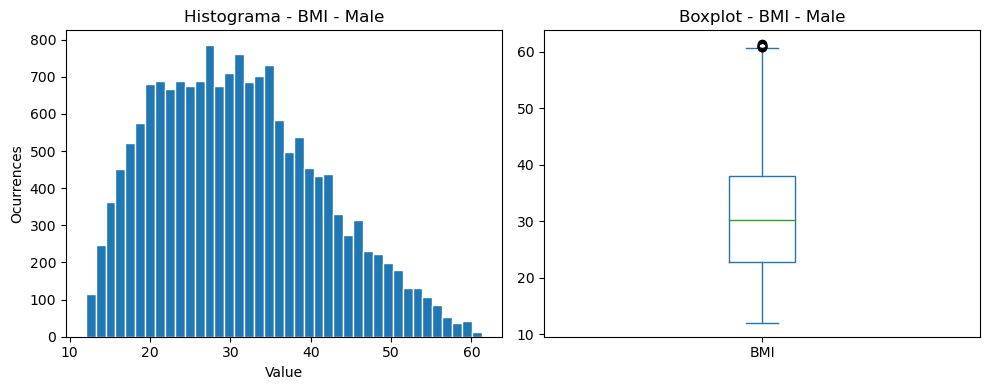

Statistics and plots for Gender = Male
Waist_Circumference_cm mean:  99.97843641583921
Waist_Circumference_cm skewness:  0.014722468246652992
Waist_Circumference_cm standart deviation:  23.06057903560086


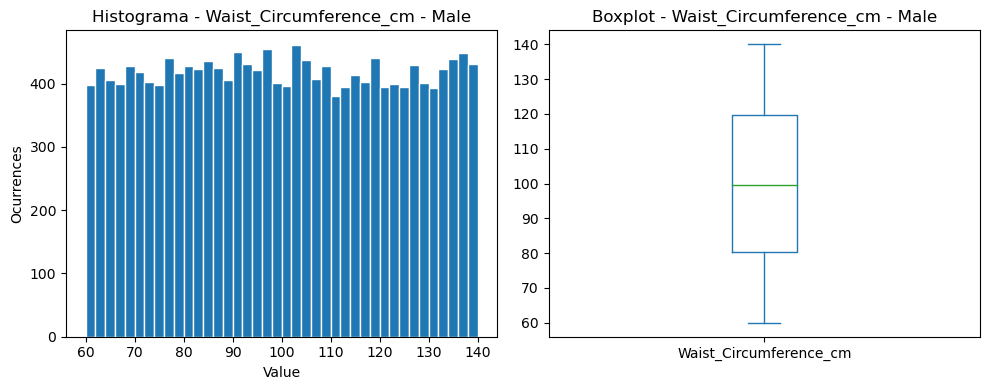

Statistics and plots for Gender = Male
Blood_Glucose mean:  160.03936902369205
Blood_Glucose skewness:  0.005284323748511412
Blood_Glucose standart deviation:  52.07738128831133


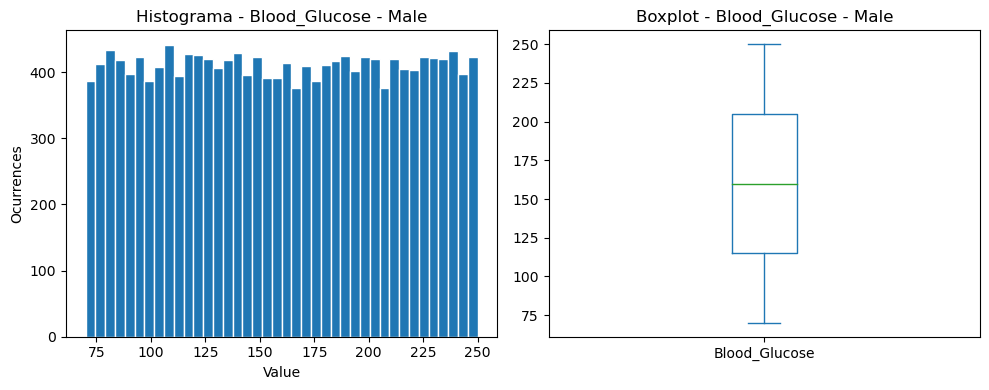

Statistics and plots for Gender = Male
HbA1c mean:  8.486384859615265
HbA1c skewness:  0.0011993474324027583
HbA1c standart deviation:  2.3135618255855492


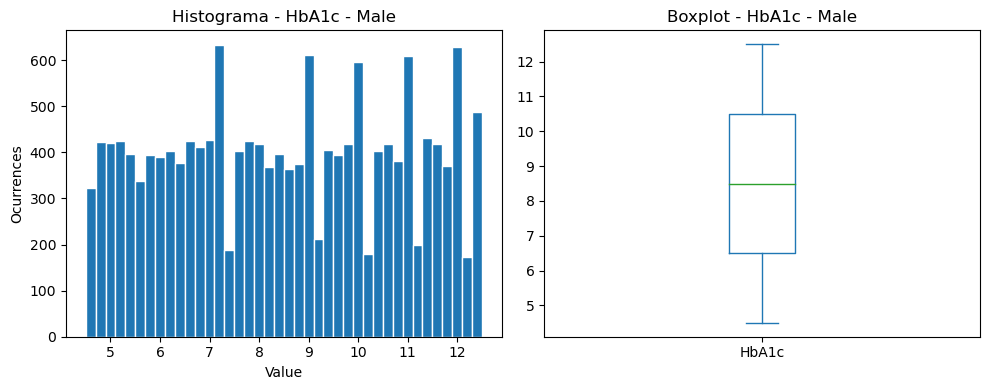

Statistics and plots for Gender = Male
Fasting_Blood_Sugar mean:  142.56685608326353
Fasting_Blood_Sugar skewness:  0.01300485642951181
Fasting_Blood_Sugar standart deviation:  44.57428116014541


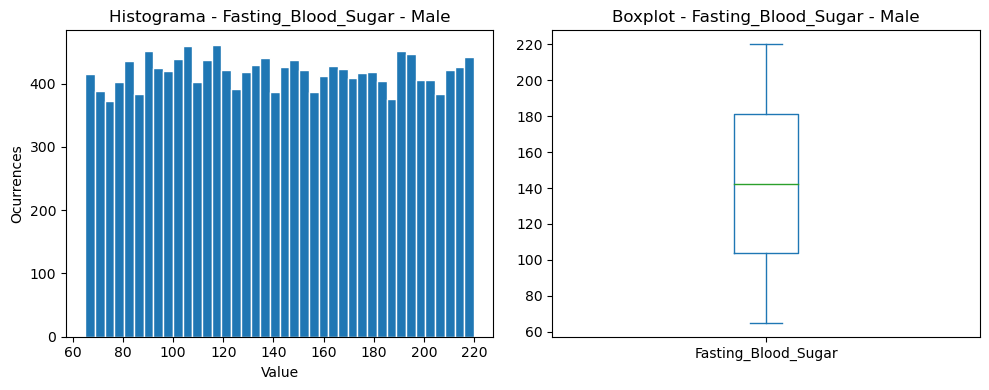

Statistics and plots for Gender = Male
Insulin_Level mean:  23.4703732503888
Insulin_Level skewness:  0.006111320552982248
Insulin_Level standart deviation:  12.380385101754568


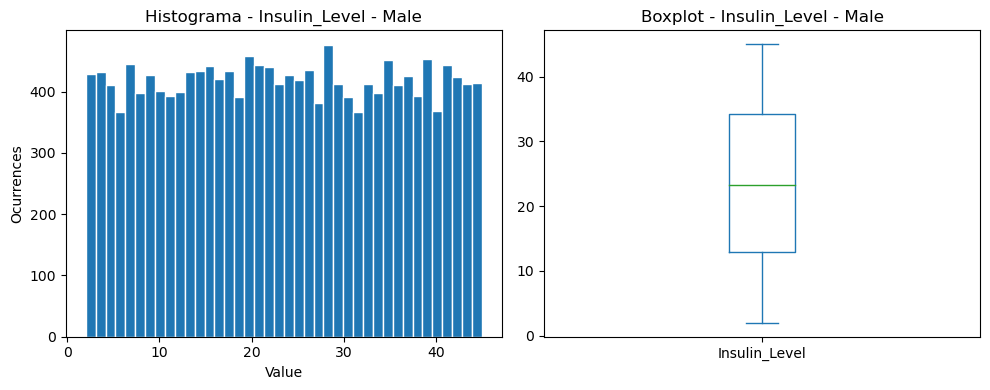

Statistics and plots for Gender = Male
Blood_Pressure_Systolic mean:  140.4012441679627
Blood_Pressure_Systolic skewness:  -0.005877044472509757
Blood_Pressure_Systolic standart deviation:  29.111712454014494


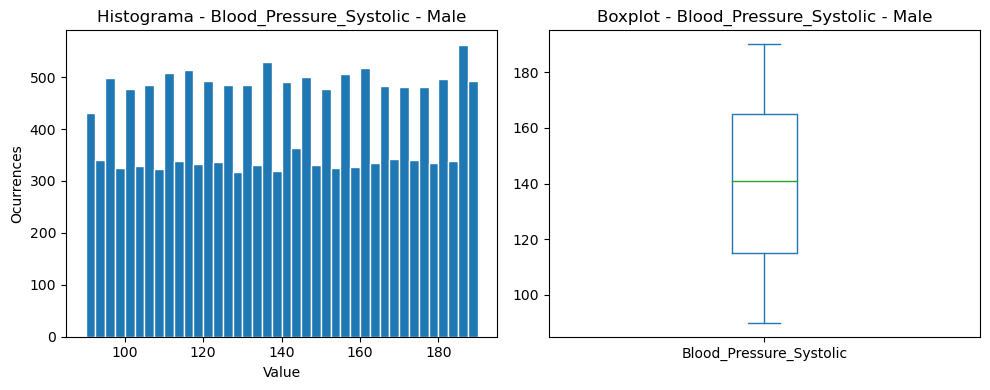

Statistics and plots for Gender = Male
Blood_Pressure_Diastolic mean:  90.08643378394545
Blood_Pressure_Diastolic skewness:  -0.00868393456653029
Blood_Pressure_Diastolic standart deviation:  17.531427958748484


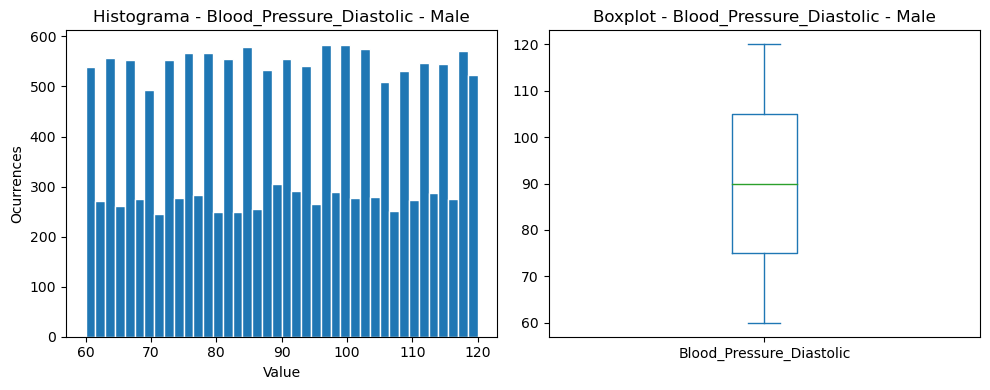

Statistics and plots for Gender = Male
Total_Cholesterol mean:  219.70787093620143
Total_Cholesterol skewness:  0.00607348764902908
Total_Cholesterol standart deviation:  57.51470602947877


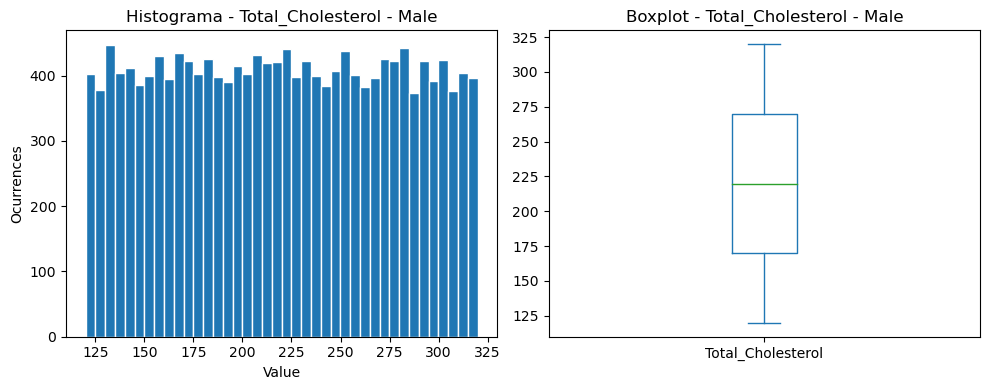

Statistics and plots for Gender = Male
HDL mean:  57.315417048579285
HDL skewness:  -0.004665883769330131
HDL standart deviation:  18.706603753007947


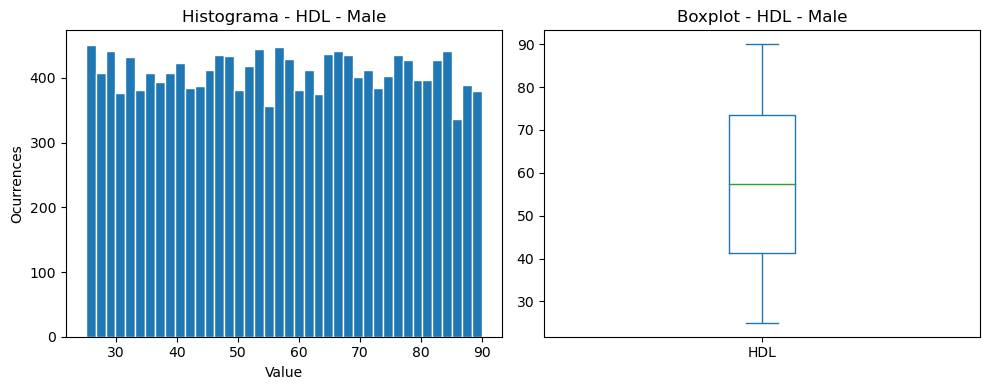

Statistics and plots for Gender = Male
LDL mean:  135.54654509971337
LDL skewness:  -0.015977297162772464
LDL standart deviation:  49.12325103443371


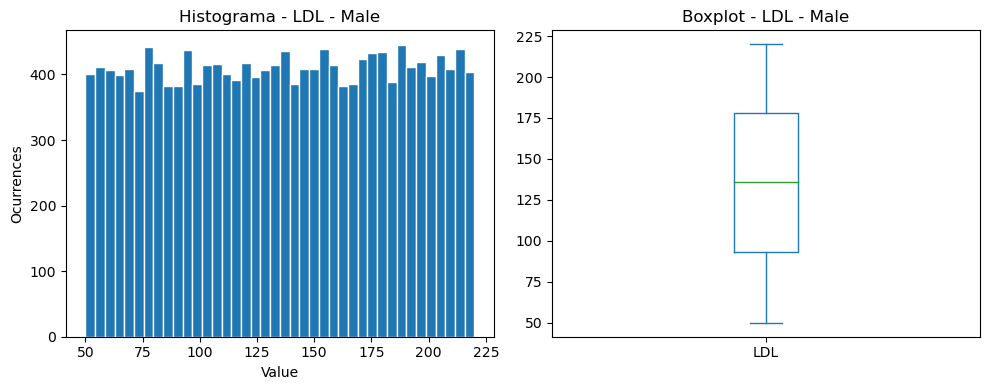

Statistics and plots for Gender = Male
Triglycerides mean:  229.53000488579454
Triglycerides skewness:  -0.0001473754890845022
Triglycerides standart deviation:  98.10359068919801


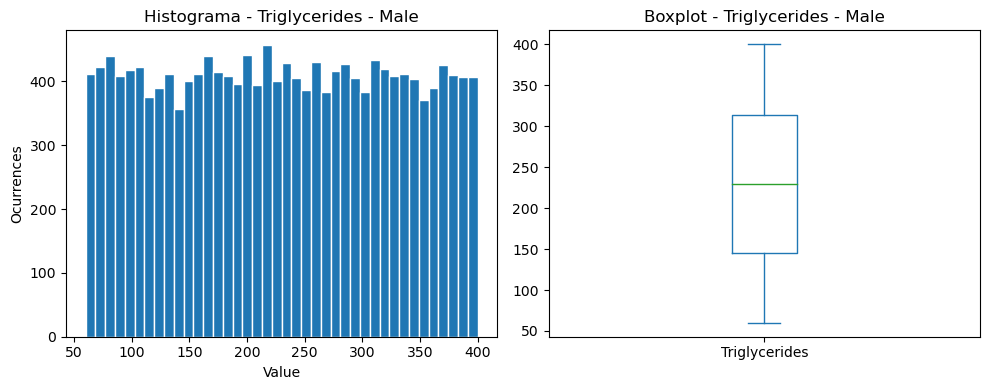

Statistics and plots for Gender = Male
Heart_Rate mean:  85.29692546955377
Heart_Rate skewness:  -0.026545856063842133
Heart_Rate standart deviation:  20.464262261509123


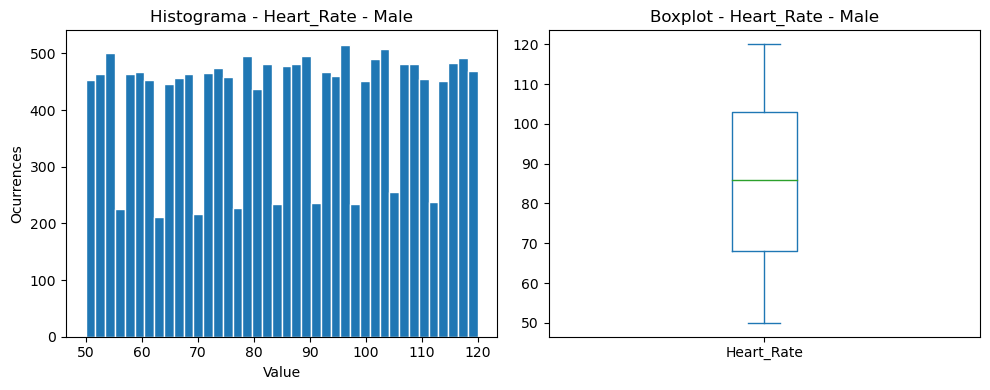

Statistics and plots for Gender = Male
Exercise_Hours_Per_Week mean:  4.993624307328311
Exercise_Hours_Per_Week skewness:  -0.0006539903983489695
Exercise_Hours_Per_Week standart deviation:  2.8702168737194254


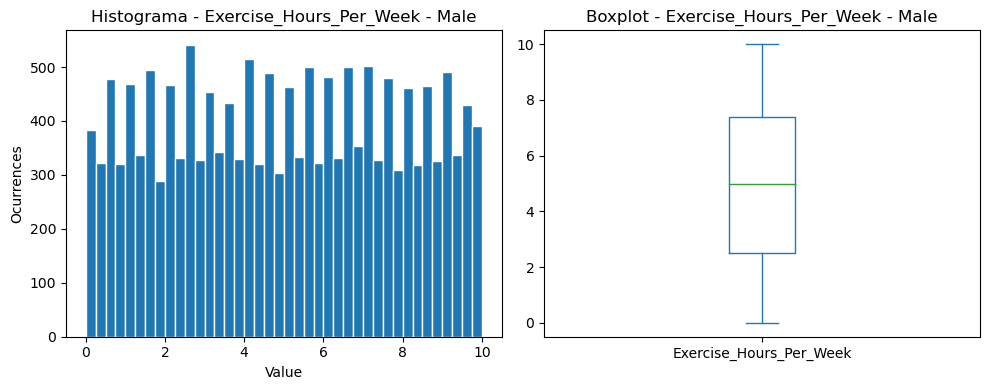

Statistics and plots for Gender = Male
Daily_Walking_Minutes mean:  89.70793680413014
Daily_Walking_Minutes skewness:  0.010696081532716619
Daily_Walking_Minutes standart deviation:  51.8709152288857


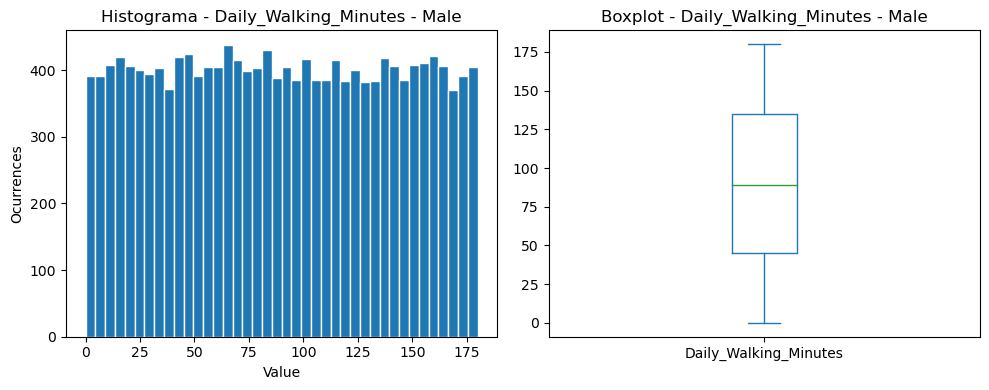

Statistics and plots for Gender = Male
Sleep_Hours mean:  6.491509257527586
Sleep_Hours skewness:  -0.002701109784345978
Sleep_Hours standart deviation:  2.030458278444412


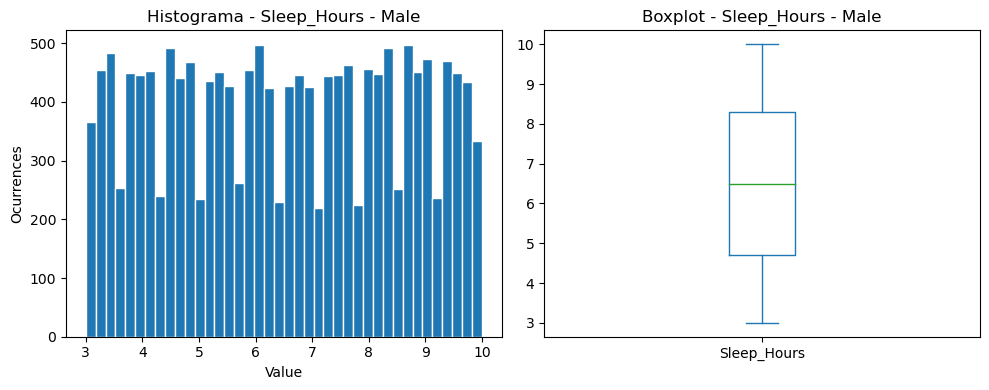

Statistics and plots for Gender = Male
Daily_Water_Intake_L mean:  2.9971886589304946
Daily_Water_Intake_L skewness:  0.0034860466738645957
Daily_Water_Intake_L standart deviation:  1.1537099769660968


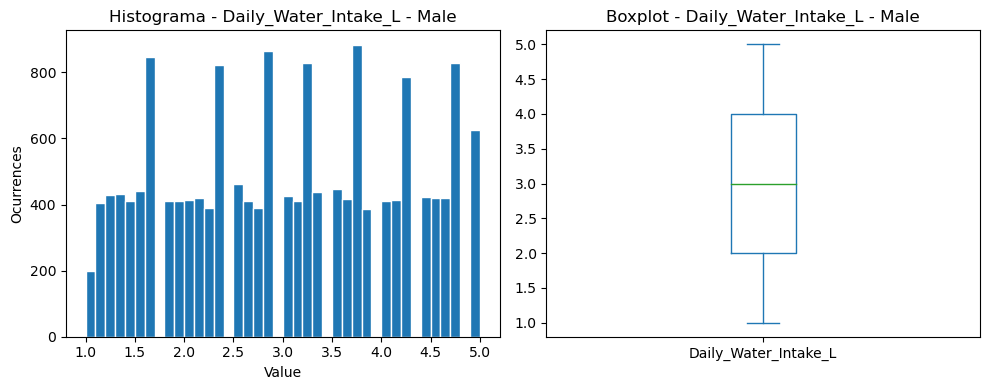

Statistics and plots for Gender = Other
Patient_ID mean:  24991.750794507407
Patient_ID skewness:  0.00852801554813026
Patient_ID standart deviation:  14446.67134360675


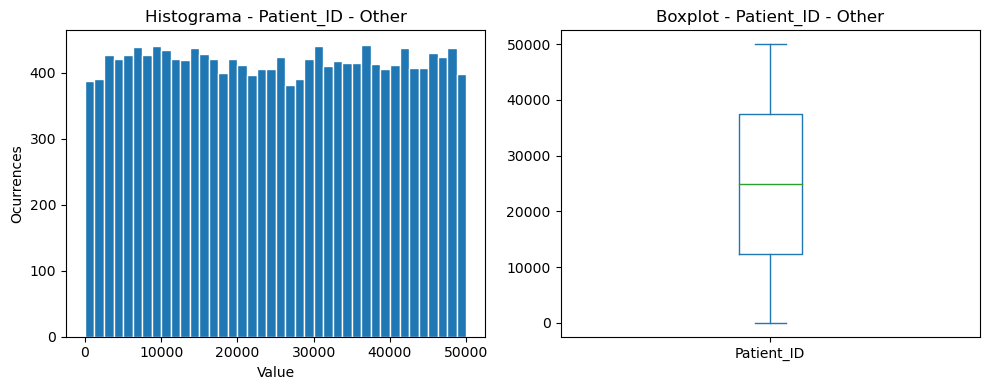

Statistics and plots for Gender = Other
Age mean:  53.82118402714658
Age skewness:  0.011657127925151355
Age standart deviation:  21.10153055612172


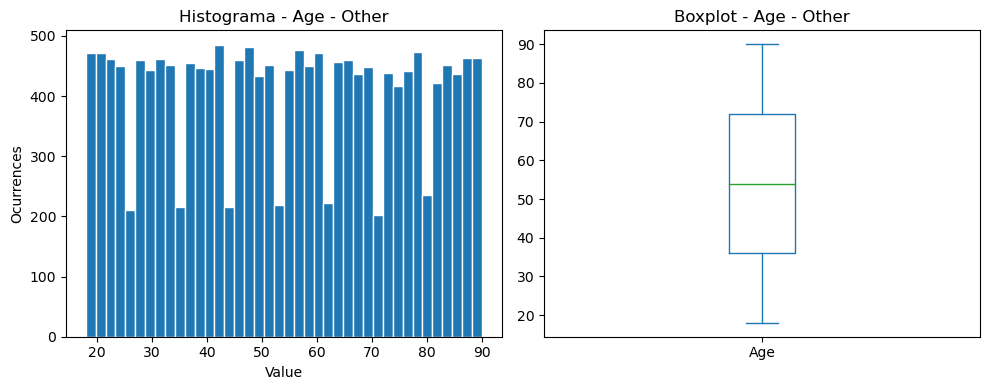

Statistics and plots for Gender = Other
Height_cm mean:  169.9398151688974
Height_cm skewness:  0.005055631868513843
Height_cm standart deviation:  14.480627629635192


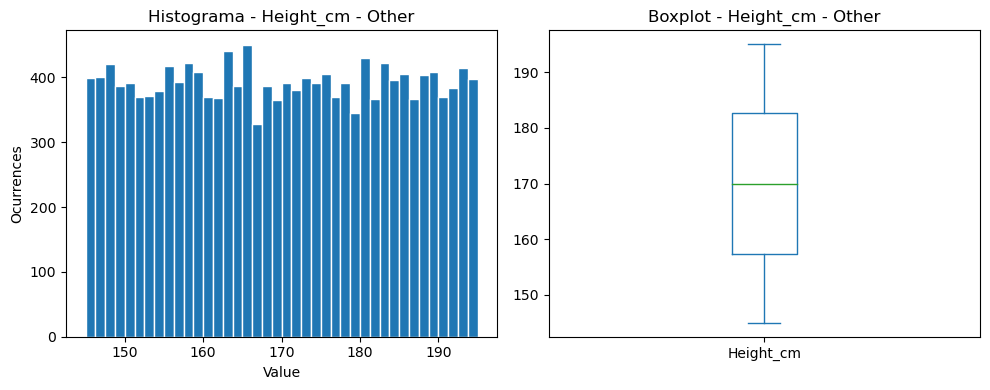

Statistics and plots for Gender = Other
Weight_kg mean:  87.33599464763603
Weight_kg skewness:  0.017873956931647502
Weight_kg standart deviation:  24.59263578961872


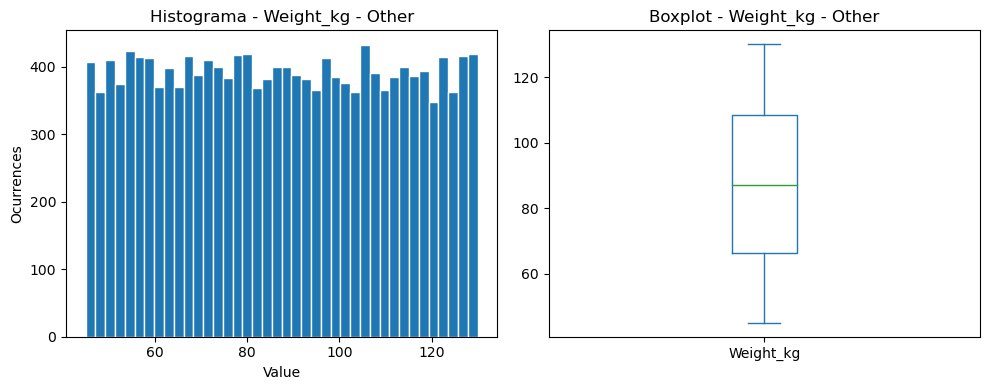

Statistics and plots for Gender = Other
BMI mean:  30.905726449601246
BMI skewness:  0.44114326530251013
BMI standart deviation:  10.296942199361705


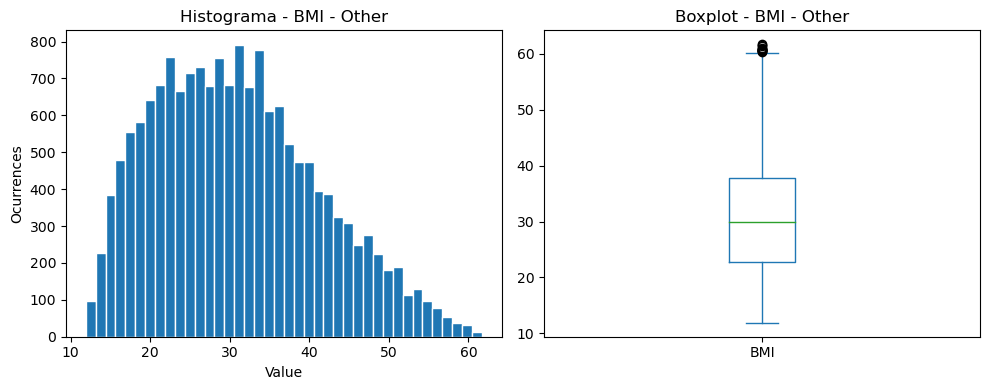

Statistics and plots for Gender = Other
Waist_Circumference_cm mean:  99.8621334772441
Waist_Circumference_cm skewness:  0.011175285655331192
Waist_Circumference_cm standart deviation:  23.12326521961333


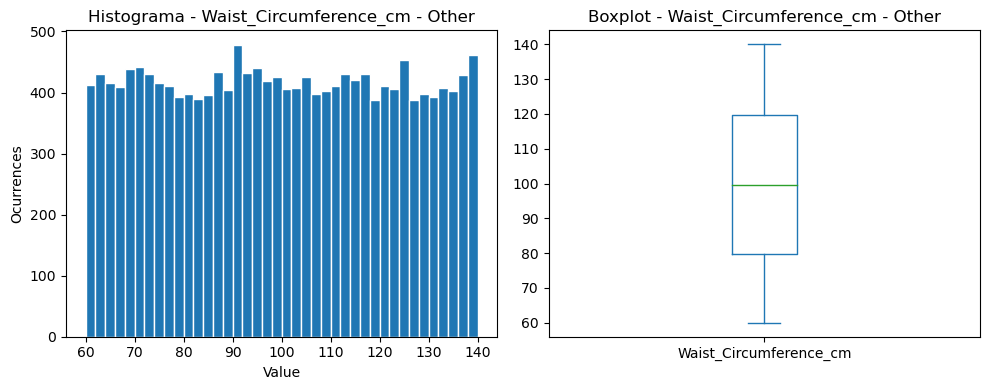

Statistics and plots for Gender = Other
Blood_Glucose mean:  159.7548315982854
Blood_Glucose skewness:  0.007140385898905199
Blood_Glucose standart deviation:  52.00660371336453


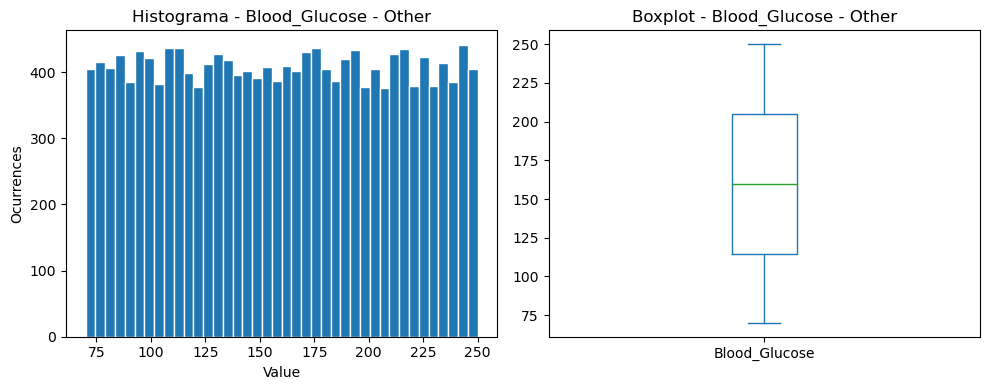

Statistics and plots for Gender = Other
HbA1c mean:  8.477049282595134
HbA1c skewness:  0.004265401495737189
HbA1c standart deviation:  2.3133596925268063


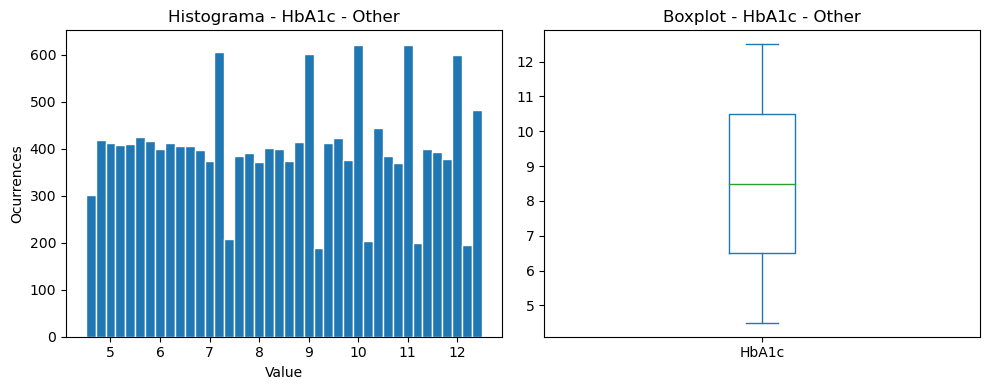

Statistics and plots for Gender = Other
Fasting_Blood_Sugar mean:  142.4227019248066
Fasting_Blood_Sugar skewness:  -0.007897924700980436
Fasting_Blood_Sugar standart deviation:  44.574776453879885


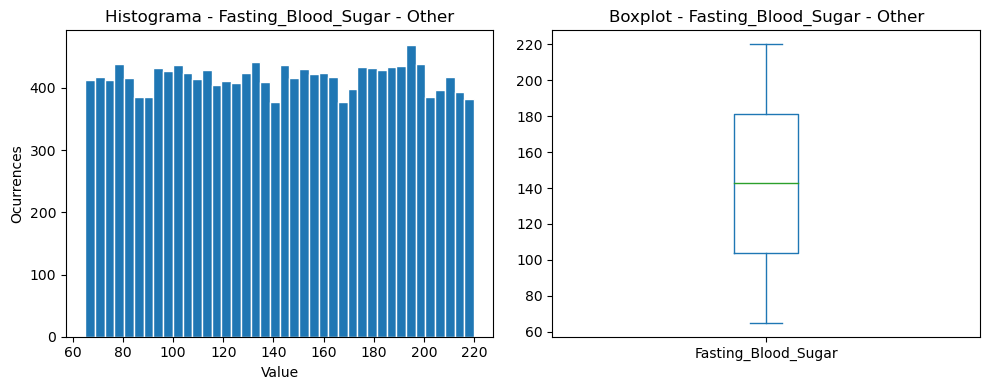

Statistics and plots for Gender = Other
Insulin_Level mean:  23.512052527432992
Insulin_Level skewness:  0.0035794973145267025
Insulin_Level standart deviation:  12.427651982076023


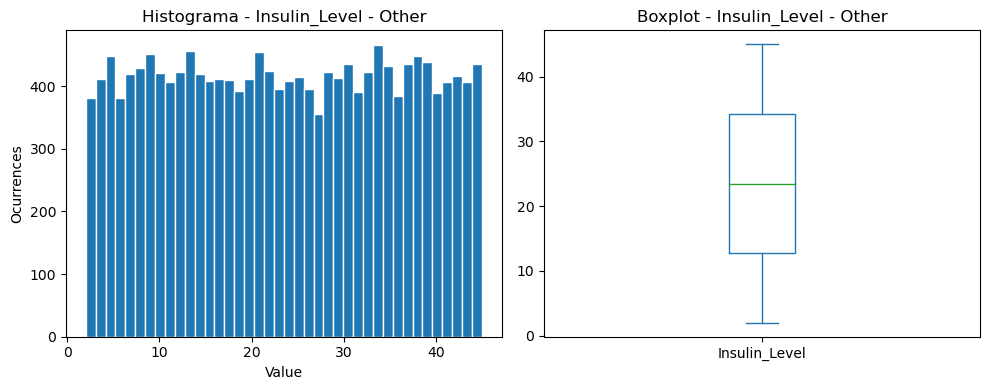

Statistics and plots for Gender = Other
Blood_Pressure_Systolic mean:  140.0799904059483
Blood_Pressure_Systolic skewness:  -0.012928793740113914
Blood_Pressure_Systolic standart deviation:  29.079793711486648


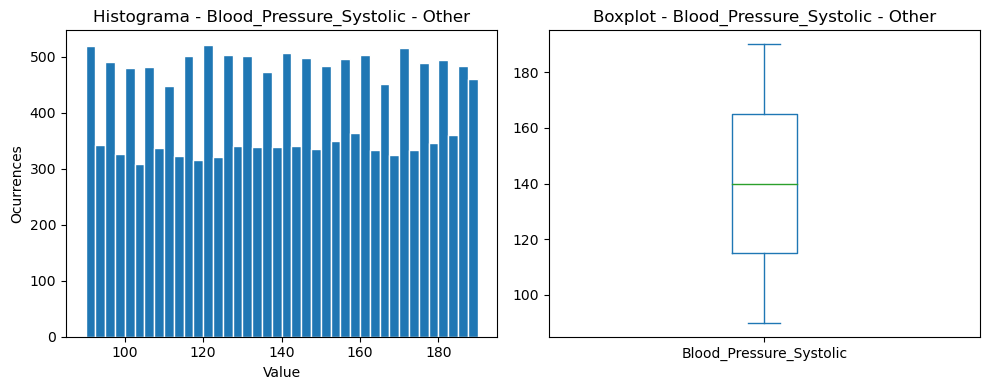

Statistics and plots for Gender = Other
Blood_Pressure_Diastolic mean:  89.97487557714217
Blood_Pressure_Diastolic skewness:  -0.005783992629851856
Blood_Pressure_Diastolic standart deviation:  17.672791656544966


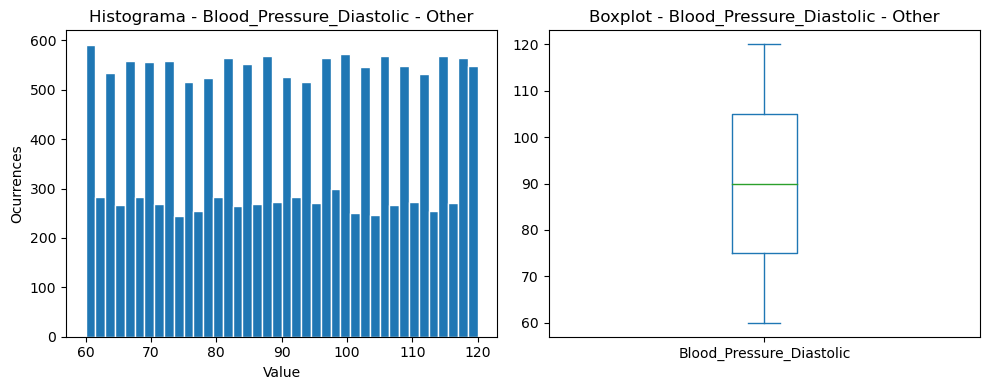

Statistics and plots for Gender = Other
Total_Cholesterol mean:  220.1710899315738
Total_Cholesterol skewness:  -0.00363890135886749
Total_Cholesterol standart deviation:  57.96972352731573


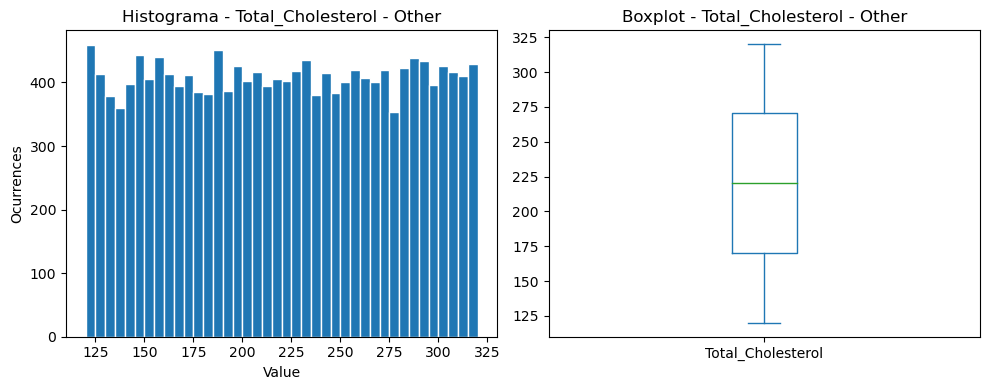

Statistics and plots for Gender = Other
HDL mean:  57.45949428937886
HDL skewness:  -0.0025624225604636832
HDL standart deviation:  18.7274286271212


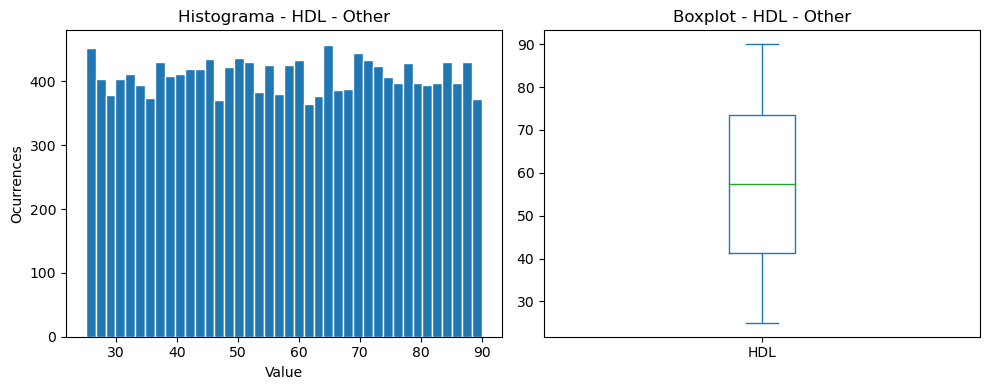

Statistics and plots for Gender = Other
LDL mean:  134.6236693992414
LDL skewness:  0.006255880509219069
LDL standart deviation:  49.21361191970681


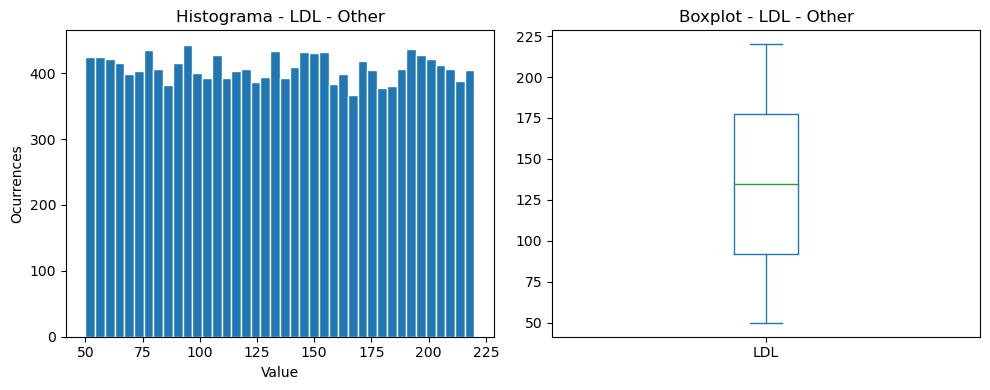

Statistics and plots for Gender = Other
Triglycerides mean:  229.58462056303551
Triglycerides skewness:  -0.0018770395322705122
Triglycerides standart deviation:  98.72859315569474


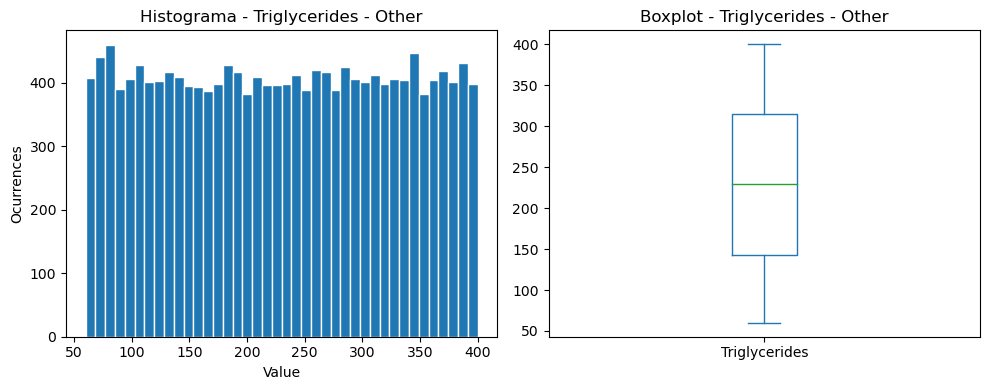

Statistics and plots for Gender = Other
Heart_Rate mean:  85.04119445943515
Heart_Rate skewness:  -0.007944884031630189
Heart_Rate standart deviation:  20.36353566443996


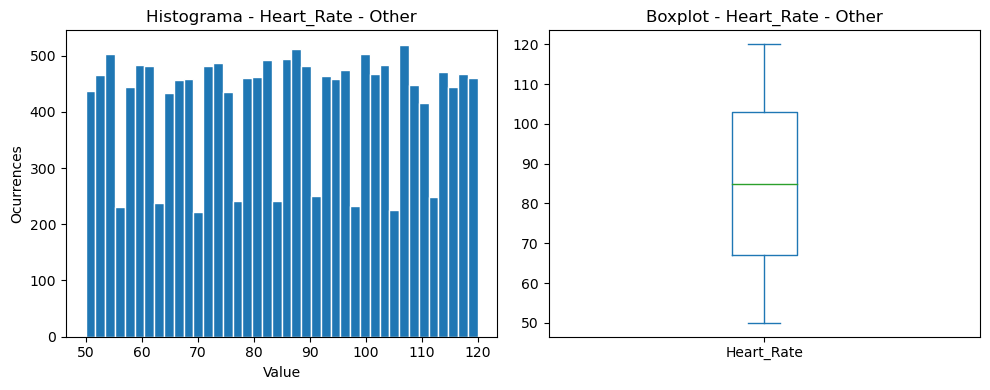

Statistics and plots for Gender = Other
Exercise_Hours_Per_Week mean:  5.003627848891664
Exercise_Hours_Per_Week skewness:  0.003116437251363803
Exercise_Hours_Per_Week standart deviation:  2.8663804844136553


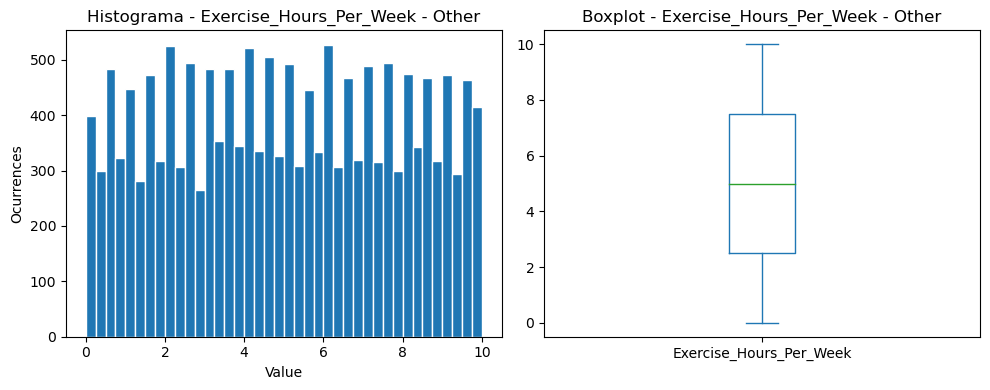

Statistics and plots for Gender = Other
Daily_Walking_Minutes mean:  89.7609551790961
Daily_Walking_Minutes skewness:  0.005566438219188674
Daily_Walking_Minutes standart deviation:  52.14679583029667


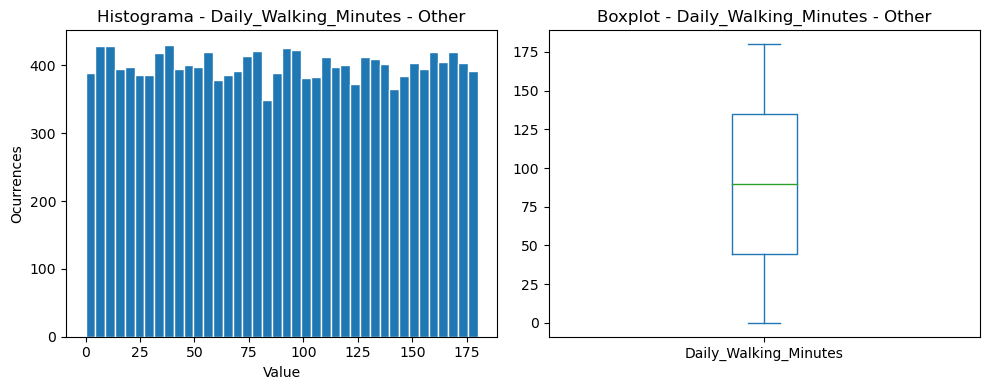

Statistics and plots for Gender = Other
Sleep_Hours mean:  6.526667916041979
Sleep_Hours skewness:  -0.019495937106939618
Sleep_Hours standart deviation:  2.023869640200395


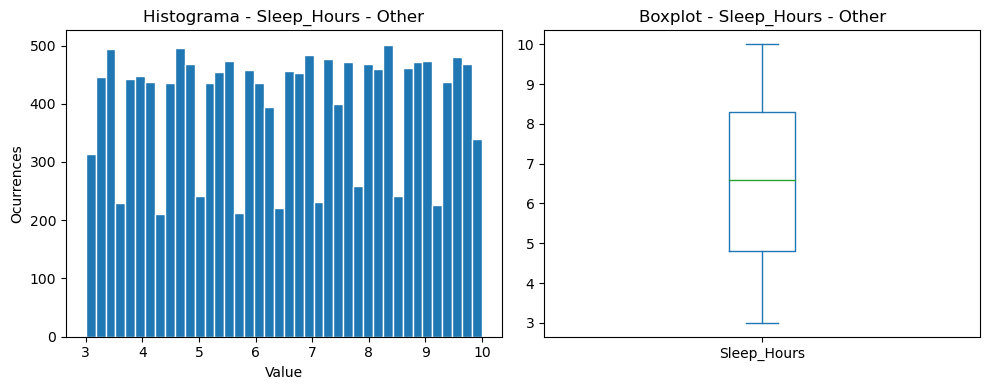

Statistics and plots for Gender = Other
Daily_Water_Intake_L mean:  2.9932781675361277
Daily_Water_Intake_L skewness:  0.013859897546757339
Daily_Water_Intake_L standart deviation:  1.1527230705973812


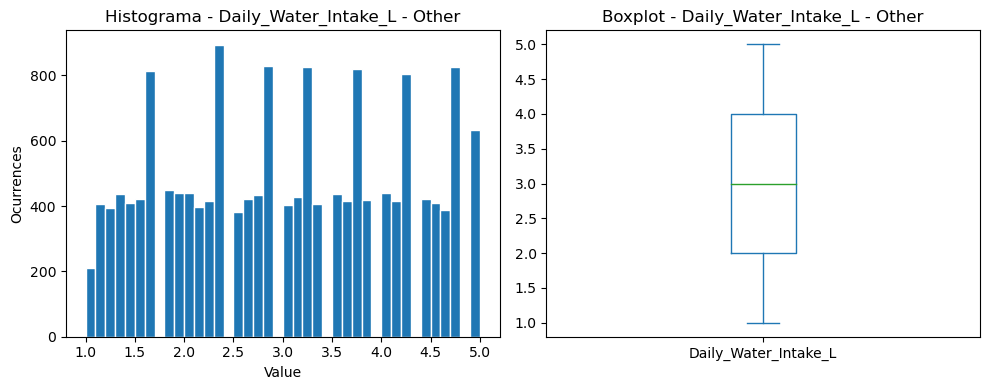

In [10]:
groups = ['Gender','Conutry']
nome_preditores_quantitativos = preditores.select_dtypes(include='number').columns

for group in groups:
    if group in preditores.columns:
        print(f'CONDITIONAL ANALYSIS ON {group} \n')
    
        for subgroup, subtable in preditores.groupby(group):
            for column in nome_preditores_quantitativos:
                print(f'Statistics and plots for {group} = {subgroup}')
                print_statistics(subtable, column)
                plot_hist_and_box(subtable, column, '- ' + subgroup)